# EDA — Restaurant Survival Classification

**Machine Learning 1 — Prof. Piotr Wójcik — a.y. 2025/2026**

Obiettivo: analisi esplorativa del dataset `restaurants_train.csv`
per validare le ipotesi del Workflow Strategy v2.0 e prendere decisioni
informate su imputazione, encoding e feature engineering.

In [1]:
from optbinning import OptimalBinning
print("✅ optbinning importato correttamente")

c:\Users\emanu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\emanu\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


(CVXPY) May 25 12:54:46 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 25 12:54:46 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')
✅ optbinning importato correttamente


In [2]:

# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', 90)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', 90)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
# === 1. CARICAMENTO DATI ===
train = pd.read_csv('Data/restaurants_train.csv')
test  = pd.read_csv('Data/restaurants_test.csv')

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print(f"\nColonne nel train ma non nel test: {set(train.columns) - set(test.columns)}")

Train shape: (33296, 86)
Test  shape: (8325, 85)

Colonne nel train ma non nel test: {'status_closed'}


In [4]:
# Prima occhiata alla struttura
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 33296 entries, 0 to 33295
Data columns (total 86 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   restaurant_id                 33296 non-null  int64  
 1   has_photo                     33296 non-null  bool   
 2   user_ratings_total            33296 non-null  float64
 3   price_level                   16361 non-null  float64
 4   category_top20                32531 non-null  str    
 5   type_meal_takeaway            33296 non-null  bool   
 6   type_meal_delivery            33296 non-null  bool   
 7   type_bar                      33296 non-null  bool   
 8   type_cafe                     33296 non-null  bool   
 9   type_night_club               33296 non-null  bool   
 10  types_count                   33296 non-null  int64  
 11  hours_open                    30649 non-null  float64
 12  hours_open_weekends           30649 non-null  float64
 13  hours_open_w

In [5]:
train.head()

,restaurant_id,has_photo,user_ratings_total,price_level,category_top20,type_meal_takeaway,type_meal_delivery,type_bar,type_cafe,type_night_club,types_count,hours_open,hours_open_weekends,hours_open_workdays,days_evenings_only,days_mornings_only,weekends_only,workdays_only,rating_5,rating_4,rating_3,rating_2,rating_1,rating_avg,rating_std,tagcat_services,tagcat_amenities,tagcat_atmosphere,tagcat_offerings,tagcat_social_inclusivity,tagcat_payment_options,place_age_days,first_review_year_max,ratings_num_1m_prior,ratings_num_3m_prior,ratings_num_6m_prior,ratings_num_9m_prior,ratings_num_12m_prior,ratings_avg_1m_prior,ratings_avg_3m_prior,ratings_avg_6m_prior,ratings_avg_9m_prior,ratings_avg_12m_prior,lang_pl_count,rating_pl,rating_foreign,foreign_lang_share,rating_mean_pl,rating_mean_foreign,rating_mean_lang_ratio,review_has_text_pct,review_length_avg,review_length_std,catch_restaurant_count_500m,catch_rating_avg_500m,catch_place_age_days_500m,catch_restaurant_count_1000m,catch_rating_avg_1000m,catch_place_age_days_1000m,catch_restaurant_count_2000m,catch_rating_avg_2000m,catch_place_age_days_2000m,residents,restaurant_count,restaurants_per_capita,urbanization,poi_count_100m,poi_count_200m,poi_count_500m,poi_count_1000m,poi_count_2000m,gus_60297,gus_60528,gus_64428,gus_79214,gus_148074,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,affiliated,status_closed
0,753641611,True,408.0000,1.0000,Kebab,False,False,False,False,False,4,68.0000,28.0000,50.0000,0.0000,0.0000,False,False,2.0000,6.0000,4.0000,1.0000,4.0000,3.0588,1.3491,3.0000,4.0000,3.0000,1.0000,1.0000,NaN,2120.0000,2016.0000,4.0000,11.0000,20.0000,23.0000,94.0000,3.2500,3.2727,3.0000,2.7826,3.7021,141.0000,535.0000,149.0000,0.1897,3.7943,4.5152,1.1900,0.4286,97.4425,151.0033,2.0000,3.9312,1575.5000,11.0000,3.1745,1478.5455,11.0000,3.1745,1478.5455,2042,4,0.0020,23,7,23,95,231,236,5438.6300,80.0000,4623.8700,7.6000,104.0000,88.0000,68.0000,42.2000,185.0000,0.0560,0.4348,-0.3788,0.0137,False,0
1,995937340,True,203.0000,NaN,Restaurant,False,False,False,False,False,4,58.0000,23.0000,43.0000,0.0000,0.0000,False,False,1.0000,5.0000,9.0000,1.0000,3.0000,3.0000,1.0761,2.0000,5.0000,5.0000,2.0000,1.0000,2.0000,663.0000,2020.0000,16.0000,57.0000,88.0000,107.0000,185.0000,4.9375,4.8421,4.8750,4.8411,4.8324,129.0000,624.0000,204.0000,0.2500,4.8372,4.7442,0.9808,0.8390,221.6279,346.8662,22.0000,3.0462,2013.6667,123.0000,3.1054,1743.0744,168.0000,3.1473,1710.0061,7537,83,0.0110,30,3,17,85,475,753,7312.2600,86.0000,7331.1500,1.9000,18354.0000,508.0000,284.0000,39.0000,273.0000,0.0583,0.3245,-0.2662,0.0173,False,0
2,426018850,True,80.0000,NaN,Pizzeria,False,False,False,False,False,4,71.0000,31.0000,51.0000,0.0000,0.0000,False,False,7.0000,1.0000,8.0000,2.0000,3.0000,3.3333,1.3916,3.0000,3.0000,1.0000,0.0000,1.0000,3.0000,22.0000,2022.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0000,327.0000,36.0000,0.0988,4.4795,4.5000,1.0046,0.7431,201.0617,187.9328,128.0000,3.2072,1533.4921,225.0000,3.2692,1462.5409,375.0000,3.2504,1570.9428,12097,128,0.0106,30,49,115,416,1229,2476,483.6400,65.0000,6062.0400,5.4000,38148.0000,7850.0000,4360.0000,30.7000,149.0000,0.0821,0.4545,-0.3724,0.0041,False,0
3,651806443,True,2.0000,NaN,Restaurant,False,False,False,False,False,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,4.5000,0.5000,1.0000,1.0000,1.0000,0.0000,NaN,NaN,301.0000,2021.0000,0.0000,0.0000,0.0000,1.0000,NaN,NaN,NaN,NaN,5.0000,NaN,1.0000,4.0000,0.0000,0.0000,4.0000,NaN,NaN,0.5000,38.0000,0.0000,9.0000,3.0334,1153.1111,39.0000,3.2747,1435.5128,205.0000,3.2488,1343.8756,6786,13,0.0019,30,5,12,71,342,1524,1532.8400,69.0000,7203.4100,2.9000,292420.0000,13051.0000,5527.0000,29.7000,199.0000,0.0853,0.3613,-0.2760,0.0074,False,0
4,658231705,False,1.0000,NaN,Restaurant,False,False,False,False,False,4,60.0000,24.0000,45.0000,0.0000,0.0000,False,False,1.0000,0.0000,0.0000,0.0000,0.0000,5.0000,0.0000,2.0000,1.0000,2.0000,0

In [6]:
train.describe()

,restaurant_id,user_ratings_total,price_level,types_count,hours_open,hours_open_weekends,hours_open_workdays,days_evenings_only,days_mornings_only,rating_5,rating_4,rating_3,rating_2,rating_1,rating_avg,rating_std,tagcat_services,tagcat_amenities,tagcat_atmosphere,tagcat_offerings,tagcat_social_inclusivity,tagcat_payment_options,place_age_days,first_review_year_max,ratings_num_1m_prior,ratings_num_3m_prior,ratings_num_6m_prior,ratings_num_9m_prior,ratings_num_12m_prior,ratings_avg_1m_prior,ratings_avg_3m_prior,ratings_avg_6m_prior,ratings_avg_9m_prior,ratings_avg_12m_prior,lang_pl_count,rating_pl,rating_foreign,foreign_lang_share,rating_mean_pl,rating_mean_foreign,rating_mean_lang_ratio,review_has_text_pct,review_length_avg,review_length_std,catch_restaurant_count_500m,catch_rating_avg_500m,catch_place_age_days_500m,catch_restaurant_count_1000m,catch_rating_avg_1000m,catch_place_age_days_1000m,catch_restaurant_count_2000m,catch_rating_avg_2000m,catch_place_age_days_2000m,residents,restaurant_count,restaurants_per_capita,urbanization,poi_count_100m,poi_count_200m,poi_count_500m,poi_count_1000m,poi_count_2000m,gus_60297,gus_60528,gus_64428,gus_79214,gus_148074,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,status_closed
count,33296.0000,33296.0000,16361.0000,33296.0000,30649.0000,30649.0000,30649.0000,30649.0000,30649.0000,33288.0000,33288.0000,33288.0000,33288.0000,33288.0000,33288.0000,33288.0000,31853.0000,31852.0000,31339.0000,29051.0000,20584.0000,9450.0000,32760.0000,32760.0000,32192.0000,31086.0000,29925.0000,29030.0000,24951.0000,25092.0000,27107.0000,27157.0000,26852.0000,23872.0000,31856.0000,31856.0000,31856.0000,31856.0000,31461.0000,28846.0000,28451.0000,32615.0000,31764.0000,31764.0000,28395.0000,28394.0000,28340.0000,30284.0000,30284.0000,30241.0000,31607.0000,31607.0000,31578.0000,33296.0000,33296.0000,32823.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000,33296.0000
mean,550737039.0653,403.6579,1.6282,4.2531,71.1704,30.1137,51.7782,0.1701,0.0952,3.2717,2.8539,2.6235,2.4262,2.8391,3.2376,1.2381,2.8011,4.1489,3.0172,1.4563,1.1885,1.7364,1463.5337,2017.8916,9.8427,30.5447,52.1165,71.6781,158.1434,4.1587,4.1298,4.1278,4.1357,4.1493,160.5431,659.7033,171.4009,0.1823,4.0569,4.4446,1.1196,0.5855,115.5025,126.0211,27.9392,3.2085,1476.6331,61.8295,3.2162,1475.2238,133.8298,3.2201,1476.7798,4282.6307,24.9710,0.0239,23.3830,12.8690,34.4796,129.1347,340.6342,846.9740,1059.1243,63.1644,5794.5899,3.5219,36784.0556,2443.4198,1107.4900,28.2831,171.6107,0.0783,0.4102,-0.3319,0.0120,0.0981
std,259381864.9572,764.4505,0.5182,0.5703,24.0284,11.0236,17.0651,0.9535,0.6193,2.4239,2.5298,2.4519,2.4434,2.4829,0.7190,0.4201,1.2844,2.4528,1.4657,1.4772,0.5578,0.9871,1041.3835,2.9019,18.0127,51.6953,81.5272,109.1373,218.0014,0.9274,0.8354,0.7948,0.7710,0.7174,226.7391,944.6871,321.4596,0.1529,0.7535,0.6789,0.2726,0.1947,53.1336,66.4366,46.9298,0.3472,507.2224,102.4241,0.2887,401.9598,229.1302,0.2461,337.1133,4148.1291,47.0664,0.1414,7.0225,18.4845,48.4596,182.2456,484.8994,1221.4769,1806.2160,31.3008,995.4211,2.2021,75175.0453,3783.8646,1637.3659,8.3182,119.3617,0.0176,0.1010,0.0967,0.0328,0.2975
min,100002731.0000,1.0000,1.0000,4.0000,0.0167,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-1.0000,-39.0000,2008.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,-15.0000,1.0000,1.0000,-9.0000,1.0000,1.0000,-24.0000,0.0000,1.0000,0.0001,10.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,4244.5600,0.0000,0.0000,2.0000,0.0000,0.0000,40.0000,0.0149,0.0000,-1.1428,0.0000,0.0000
25%,326499914.7500,35.0000,1.0000,4.0000,58.0000,24.0000,42.500

# ---
2. TARGET — Sbilanciamento di `status_closed`
Conoscere la proporzione esatta ci dice quanto aggressivo
dovrà essere il `class_weight='balanced'`.

In [7]:
target_counts = train['status_closed'].value_counts()
target_pct    = train['status_closed'].value_counts(normalize=True) * 100

print("Conteggi assoluti:")
print(target_counts)
print(f"\nProporzioni:")
print(target_pct.round(2))
print(f"\nRapporto Classe 0 / Classe 1: {target_counts[0] / target_counts[1]:.2f}")

Conteggi assoluti:
status_closed
0    30028
1     3268
Name: count, dtype: int64

Proporzioni:
status_closed
0   90.1900
1    9.8100
Name: proportion, dtype: float64

Rapporto Classe 0 / Classe 1: 9.19


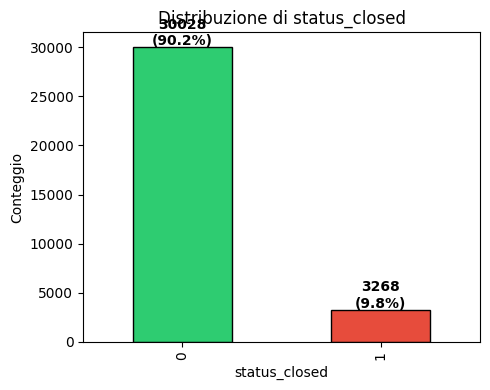

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
target_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=ax)
ax.set_title('Distribuzione di status_closed')
ax.set_xlabel('status_closed')
ax.set_ylabel('Conteggio')
for i, v in enumerate(target_counts):
    ax.text(i, v + 200, f'{v}\n({target_pct.iloc[i]:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3. VARIABILI PROBLEMATICHE — Tipi e valori inattesi


 3a. `weekends_only` e `workdays_only` (String, non Boolean)

In [9]:
print("=== weekends_only ===")
print(f"Dtype: {train['weekends_only'].dtype}")
print(train['weekends_only'].value_counts(dropna=False))
print()
print("=== workdays_only ===")
print(f"Dtype: {train['workdays_only'].dtype}")
print(train['workdays_only'].value_counts(dropna=False))

=== weekends_only ===
Dtype: object
weekends_only
False    30615
NaN       2647
True        34
Name: count, dtype: int64

=== workdays_only ===
Dtype: object
workdays_only
False    30613
NaN       2647
True        36
Name: count, dtype: int64


3b. `price_level` — Valori unici (aspettati: 1-4 categorica)

In [10]:
print(f"Dtype: {train['price_level'].dtype}")
print(f"\nValori unici: {sorted(train['price_level'].dropna().unique())}")
print(f"\nDistribuzione (inclusi NaN):")
print(train['price_level'].value_counts(dropna=False).sort_index())

Dtype: float64

Valori unici: [1.0, 2.0, 3.0, 4.0]

Distribuzione (inclusi NaN):
price_level
1.0000     6352
2.0000     9757
3.0000      235
4.0000       17
NaN       16935
Name: count, dtype: int64


3c. `first_review_year_max` — Controllo valori anomali

In [11]:
print(f"Dtype: {train['first_review_year_max'].dtype}")
print(f"Min: {train['first_review_year_max'].min()}, Max: {train['first_review_year_max'].max()}")
print(f"NaN: {train['first_review_year_max'].isna().sum()}")
print(f"\nDistribuzione:")
print(train['first_review_year_max'].value_counts(dropna=False).sort_index())

Dtype: float64
Min: 2008.0, Max: 2022.0
NaN: 536

Distribuzione:
first_review_year_max
2008.0000       1
2009.0000       6
2010.0000      57
2011.0000     554
2012.0000    1035
2013.0000    1588
2014.0000    1237
2015.0000    1839
2016.0000    3704
2017.0000    4461
2018.0000    3514
2019.0000    3563
2020.0000    3380
2021.0000    4276
2022.0000    3545
NaN           536
Name: count, dtype: int64


# ---
 4. CARDINALITÀ DI `category_top20`

In [12]:
cat_counts = train['category_top20'].value_counts(dropna=False)
cat_pct    = train['category_top20'].value_counts(dropna=False, normalize=True) * 100

cat_summary = pd.DataFrame({
    'count': cat_counts,
    'pct': cat_pct.round(2)
})
print(f"Numero di categorie uniche: {train['category_top20'].nunique()}")
print(f"\nDistribuzione completa:")
print(cat_summary)

Numero di categorie uniche: 20

Distribuzione completa:
                                count     pct
category_top20                               
Restaurant                      15507 46.5700
Other                            4505 13.5300
Pizzeria                         3737 11.2200
Kebab                            1685  5.0600
Fast food                        1152  3.4600
NaN                               765  2.3000
Bistro                            747  2.2400
Polish cuisine                    602  1.8100
Pub                               585  1.7600
Sushi                             561  1.6800
Burgers                           427  1.2800
Bar                               410  1.2300
Family restaurant                 364  1.0900
Italian cuisine                   359  1.0800
Pierogi restaurant                327  0.9800
Vietnamese cuisine                324  0.9700
Turkish cuisine                   259  0.7800
Hot dogs                          251  0.7500
Healthy food            

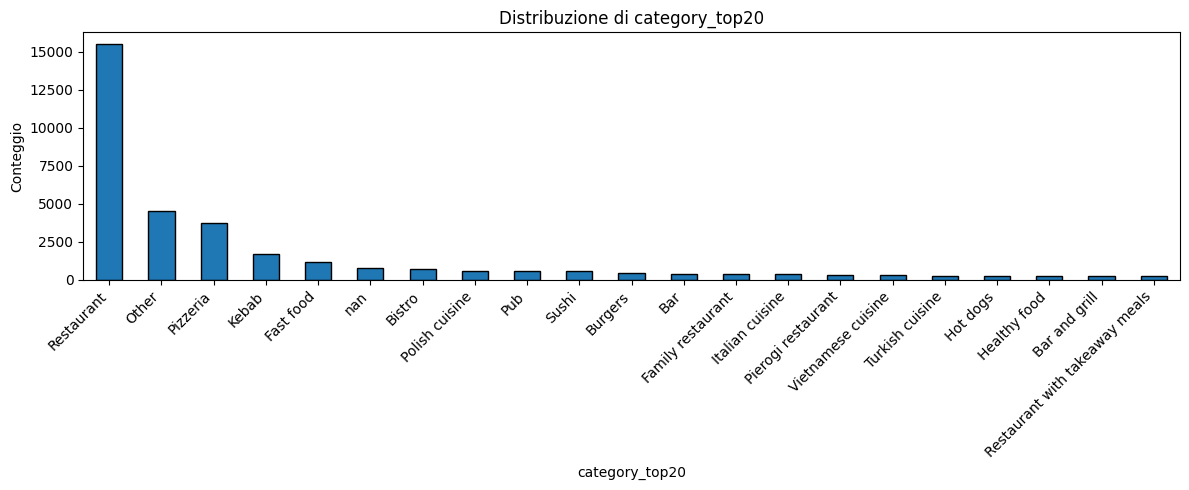

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
cat_counts.plot(kind='bar', edgecolor='black', ax=ax)
ax.set_title('Distribuzione di category_top20')
ax.set_ylabel('Conteggio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---
5. MISSING VALUES — Pattern e concentrazione

In [14]:
# Conteggio e percentuale di NaN per colonna
missing_count = train.isnull().sum()
missing_pct   = (train.isnull().sum() / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'n_missing': missing_count,
    'pct_missing': missing_pct
}).query('n_missing > 0').sort_values('pct_missing', ascending=False)

print(f"Colonne con almeno 1 NaN: {len(missing_df)} su {train.shape[1]}")
print(f"\n{missing_df}")


Colonne con almeno 1 NaN: 54 su 86

                              n_missing  pct_missing
tagcat_payment_options            23846      71.6200
price_level                       16935      50.8600
tagcat_social_inclusivity         12712      38.1800
ratings_avg_12m_prior              9424      28.3000
ratings_num_12m_prior              8345      25.0600
ratings_avg_1m_prior               8204      24.6400
ratings_avg_9m_prior               6444      19.3500
ratings_avg_3m_prior               6189      18.5900
ratings_avg_6m_prior               6139      18.4400
catch_place_age_days_500m          4956      14.8800
catch_rating_avg_500m              4902      14.7200
catch_restaurant_count_500m        4901      14.7200
rating_mean_lang_ratio             4845      14.5500
rating_mean_foreign                4450      13.3600
ratings_num_9m_prior               4266      12.8100
tagcat_offerings                   4245      12.7500
ratings_num_6m_prior               3371      10.1200
catch_plac

C:\Users\emanu\AppData\Local\Temp\ipykernel_38720\2220993365.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


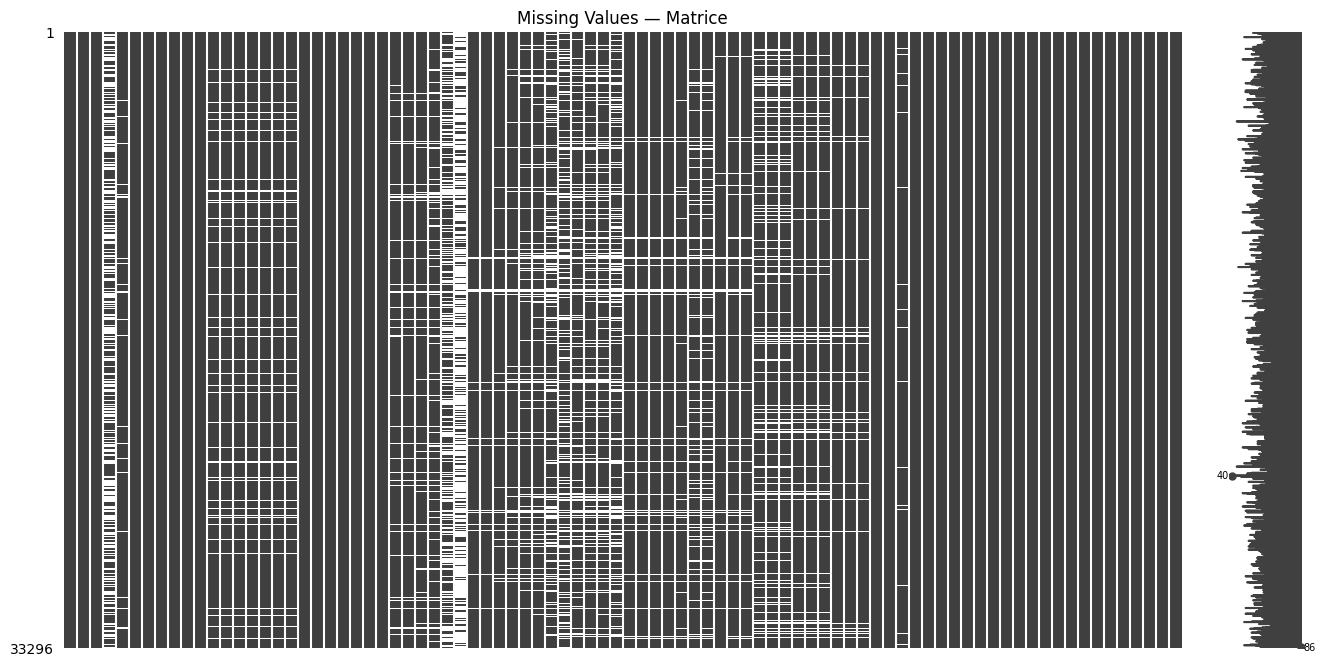

In [15]:
# Visualizzazione con missingno — matrice
msno.matrix(train, figsize=(16, 8), fontsize=8)
plt.title('Missing Values — Matrice')
plt.tight_layout()
plt.show()

In [16]:
# Verifica dell'ipotesi: i NaN nelle variabili di rating coincidono
# con user_ratings_total == 0?

rating_vars = ['rating_avg', 'rating_std', 'review_length_avg',
               'ratings_avg_12m_prior', 'ratings_num_12m_prior']

# Quanti locali hanno 0 recensioni totali?
zero_ratings = (train['user_ratings_total'] == 0).sum()
print(f"Locali con user_ratings_total == 0: {zero_ratings} ({zero_ratings/len(train)*100:.2f}%)")

# Per ogni variabile di rating, quanti NaN coincidono con user_ratings_total == 0?
print(f"\nSovrapposizione NaN ↔ user_ratings_total == 0:")
for var in rating_vars:
    nan_mask = train[var].isna()
    overlap  = (nan_mask & (train['user_ratings_total'] == 0)).sum()
    total_nan = nan_mask.sum()
    if total_nan > 0:
        print(f"  {var}: {total_nan} NaN totali, {overlap} coincidono con ratings=0 ({overlap/total_nan*100:.1f}%)")
    else:
        print(f"  {var}: nessun NaN")

Locali con user_ratings_total == 0: 0 (0.00%)

Sovrapposizione NaN ↔ user_ratings_total == 0:
  rating_avg: 8 NaN totali, 0 coincidono con ratings=0 (0.0%)
  rating_std: 8 NaN totali, 0 coincidono con ratings=0 (0.0%)
  review_length_avg: 1532 NaN totali, 0 coincidono con ratings=0 (0.0%)
  ratings_avg_12m_prior: 9424 NaN totali, 0 coincidono con ratings=0 (0.0%)
  ratings_num_12m_prior: 8345 NaN totali, 0 coincidono con ratings=0 (0.0%)


In [17]:
# Selezioniamo solo le colonne numeriche
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# Rimuoviamo restaurant_id e il target
numeric_cols = [c for c in numeric_cols if c not in ['restaurant_id', 'status_closed']]

corr_matrix = train[numeric_cols].corr(method='spearman')

In [18]:
# Estraiamo le coppie con |ρ| > 0.90
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.90:
            high_corr_pairs.append({
                'var_1': corr_matrix.columns[i],
                'var_2': corr_matrix.columns[j],
                'spearman_rho': round(rho, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('spearman_rho',
                                                           key=abs,
                                                           ascending=False)
print(f"Coppie con |Spearman ρ| > 0.90: {len(high_corr_df)}")
print()
print(high_corr_df.to_string(index=False))

Coppie con |Spearman ρ| > 0.90: 30

                       var_1                        var_2  spearman_rho
               lang_pl_count                    rating_pl        0.9947
              place_age_days        first_review_year_max       -0.9943
                  gus_153354                   gus_153398        0.9922
        ratings_num_6m_prior         ratings_num_9m_prior        0.9901
        ratings_num_9m_prior        ratings_num_12m_prior        0.9815
        ratings_num_3m_prior         ratings_num_6m_prior        0.9798
             gus_60528_ratio        gus_1548707_net_ratio       -0.9792
                  hours_open          hours_open_workdays        0.9728
        ratings_num_6m_prior        ratings_num_12m_prior        0.9698
        ratings_num_3m_prior         ratings_num_9m_prior        0.9623
          user_ratings_total                lang_pl_count        0.9526
             poi_count_1000m              poi_count_2000m        0.9500
              poi_count_500m

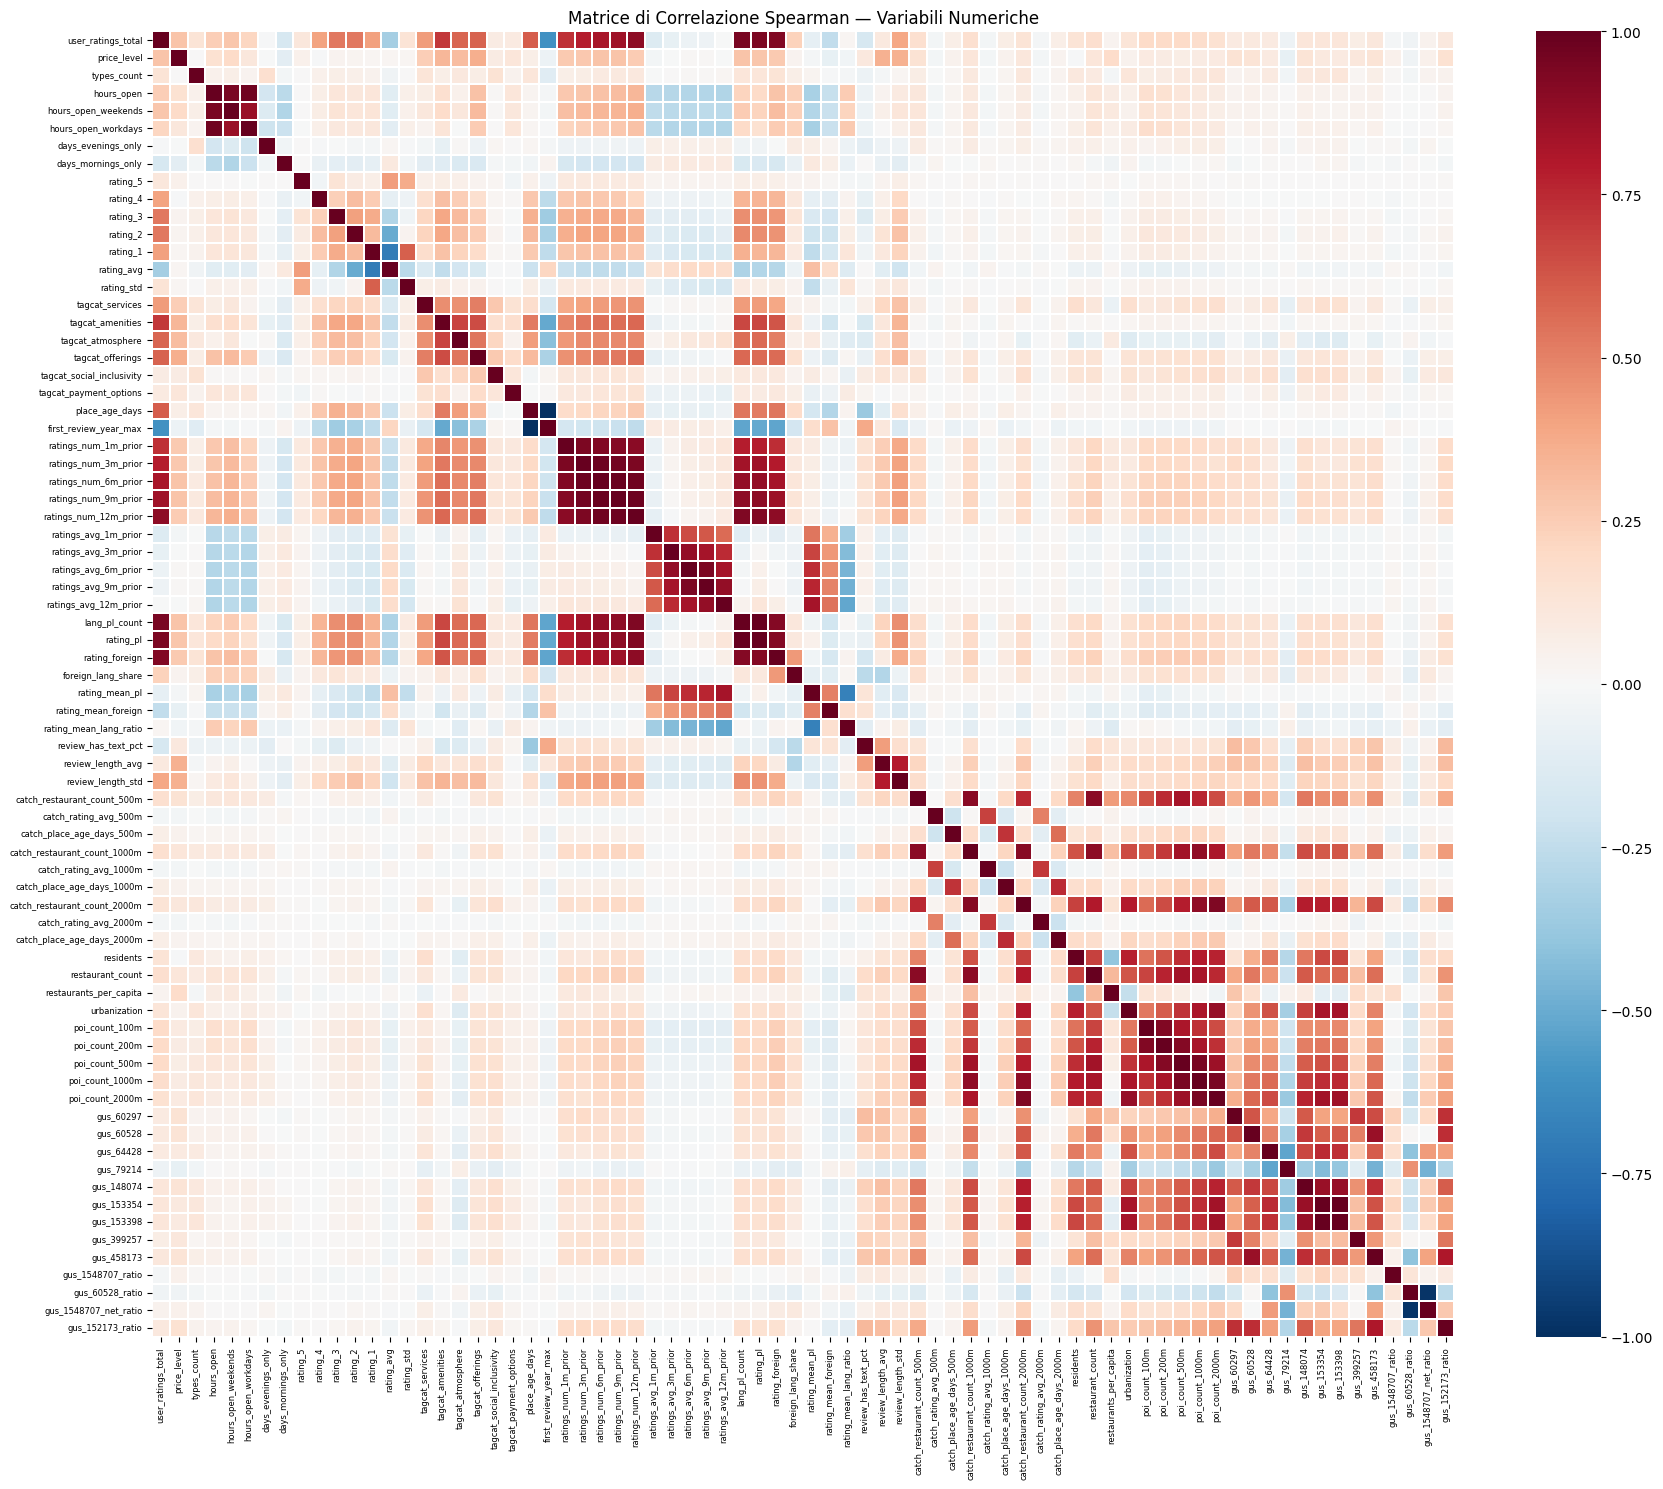

In [19]:
# Heatmap della matrice di correlazione (overview compatta)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Matrice di Correlazione Spearman — Variabili Numeriche')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

# ---
7. DISTRIBUZIONI — Code e asimmetria delle variabili di conteggio
Obiettivo: decidere se servono PowerTransformer o RobustScaler.

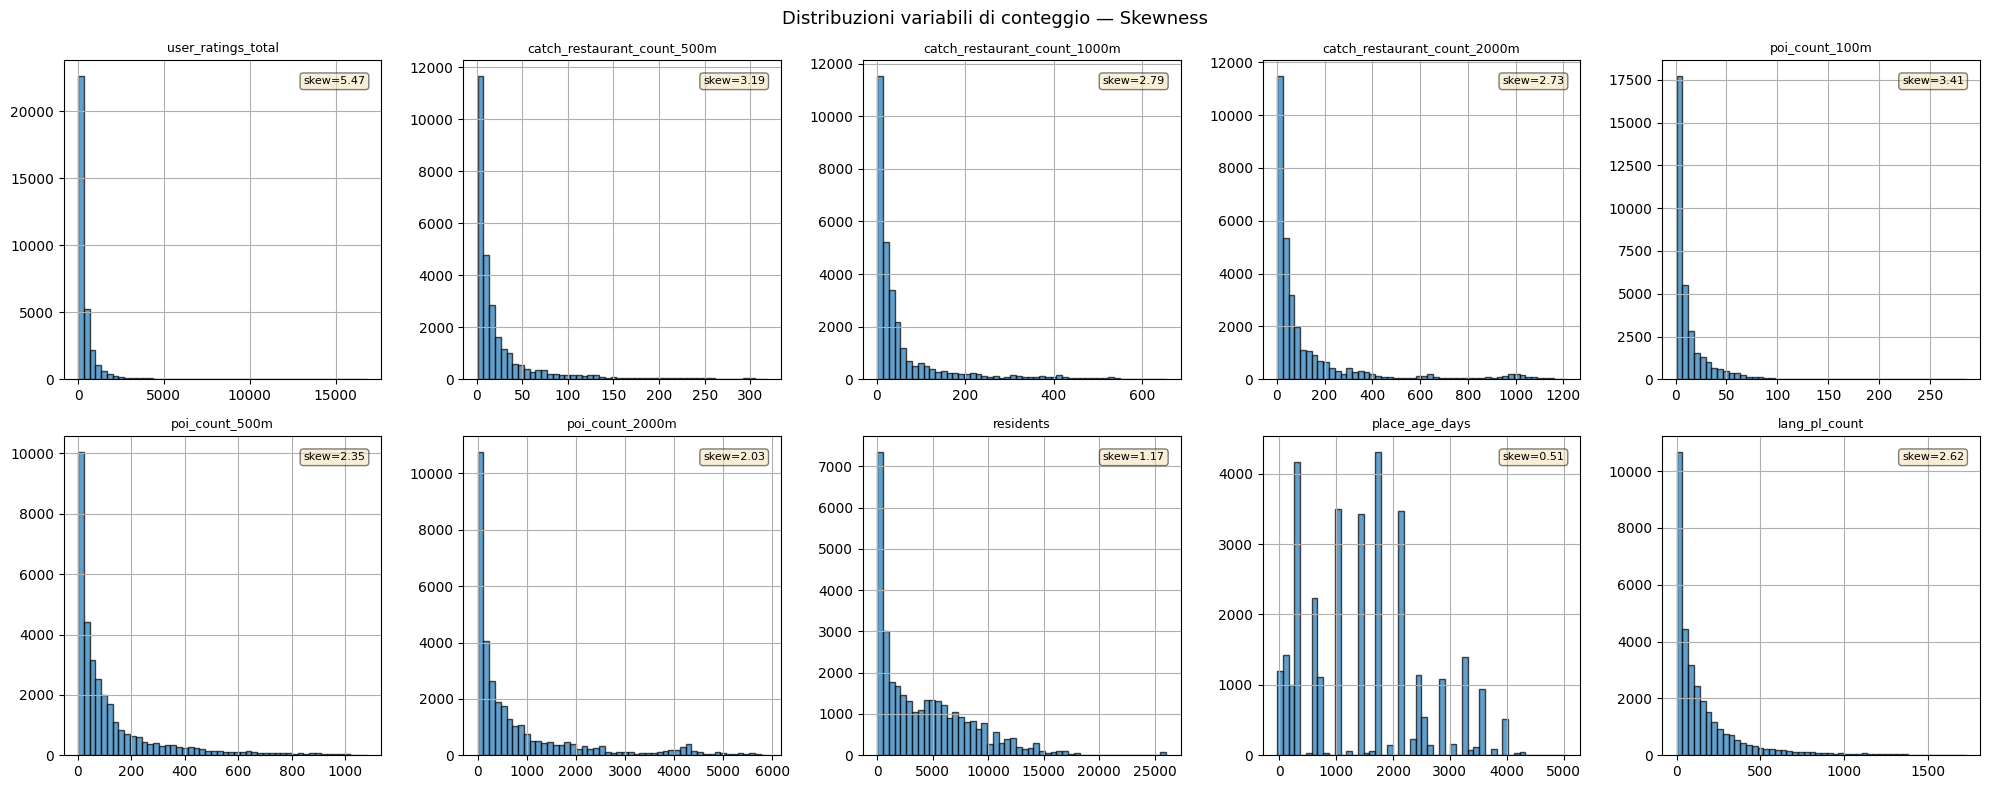

In [20]:
count_vars = ['user_ratings_total', 'catch_restaurant_count_500m',
              'catch_restaurant_count_1000m', 'catch_restaurant_count_2000m',
              'poi_count_100m', 'poi_count_500m', 'poi_count_2000m',
              'residents', 'place_age_days', 'lang_pl_count']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, var in enumerate(count_vars):
    ax = axes[i]
    train[var].dropna().hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(var, fontsize=9)
    skew_val = train[var].skew()
    ax.text(0.95, 0.95, f'skew={skew_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribuzioni variabili di conteggio — Skewness', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Skewness tabellare per tutte le numeriche
skewness = train[numeric_cols].skew().sort_values(ascending=False)
print("Top 15 variabili per skewness (più asimmetriche):")
print(skewness.head(15).round(3))
print(f"\n...e le 5 meno asimmetriche:")
print(skewness.tail(5).round(3))

Top 15 variabili per skewness (più asimmetriche):
restaurants_per_capita   14.7900
days_mornings_only        8.0890
ratings_num_1m_prior      6.8000
rating_mean_lang_ratio    6.6710
days_evenings_only        5.9820
gus_152173_ratio          5.5100
user_ratings_total        5.4650
ratings_num_3m_prior      5.3940
rating_foreign            5.2030
review_length_avg         5.1220
ratings_num_6m_prior      4.6610
gus_60297                 4.2920
ratings_num_9m_prior      4.2170
gus_458173                3.8430
restaurant_count          3.4770
dtype: float64

...e le 5 meno asimmetriche:
ratings_avg_3m_prior    -1.7430
ratings_avg_6m_prior    -1.8350
ratings_avg_9m_prior    -1.9090
ratings_avg_12m_prior   -2.1950
rating_mean_foreign     -2.9110
dtype: float64


 # 02 — Data Preparation: Missing Values & Encoding

 **Machine Learning 1 — Prof. Piotr Wójcik — a.y. 2025/2026**



 Questo script applica la strategia di imputazione e encoding

 concordata nell'analisi del Workflow Strategy v2.0.

 Tutto ciò che è fatto qui è PRE-PIPELINE (trasformazioni deterministiche

 che non dipendono da statistiche del training set, quindi no data leakage).

 Le trasformazioni che dipendono dal training set (mediana, scaling)

 saranno incapsulate nella Pipeline nello step successivo.

In [49]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 90)
pd.set_option('display.float_format', '{:.4f}'.format)


In [50]:
# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train.csv')
test  = pd.read_csv('Data/restaurants_test.csv')

# Salviamo target e id prima di qualsiasi trasformazione
target = train['status_closed'].copy()
train_id = train['restaurant_id'].copy()
test_id  = test['restaurant_id'].copy()

# Uniamo train e test per applicare le trasformazioni deterministiche
# in modo coerente. Aggiungiamo un flag per separarli dopo.
train['_is_train'] = 1
test['_is_train']  = 0
# Aggiungiamo status_closed al test come NaN per poter fare concat
test['status_closed'] = np.nan

df = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Dataset combinato: {df.shape}")


Dataset combinato: (41621, 87)


In [51]:
raw = pd.read_csv('Data/restaurants_train.csv')

print("weekends_only:")
print(f"  dtype: {raw['weekends_only'].dtype}")
print(f"  unique: {raw['weekends_only'].unique()[:20]}")
print(f"  value_counts:")
print(raw['weekends_only'].value_counts(dropna=False))

print("\nDopo astype(str).str.strip():")
temp = raw['weekends_only'].astype(str).str.strip()
print(f"  unique: {temp.unique()[:20]}")
print(f"  value_counts:")
print(temp.value_counts(dropna=False))

weekends_only:
  dtype: object
  unique: [False nan True]
  value_counts:
weekends_only
False    30615
NaN       2647
True        34
Name: count, dtype: int64

Dopo astype(str).str.strip():
  unique: <ArrowStringArray>
['False', nan, 'True']
Length: 3, dtype: str
  value_counts:
weekends_only
False    30615
NaN       2647
True        34
Name: count, dtype: int64


 ---

 ## GRUPPO 0 — Indicatore sintetico `is_new_restaurant`

 Proxy unico per tutti i missing fisiologici.

 Cattura il segnale "questo locale non ha attività recensoria".

In [52]:
df['is_new_restaurant'] = (df['user_ratings_total'] == 0).astype(int)
print(f"Locali 'nuovi' (user_ratings_total == 0): {df['is_new_restaurant'].sum()} "
      f"({df['is_new_restaurant'].mean()*100:.2f}%)")


Locali 'nuovi' (user_ratings_total == 0): 0 (0.00%)


 ---

 ## GRUPPO 1 — NaN fisiologici → imputazione a 0

 Variabili dove NaN = "nessuna recensione / locale troppo recente".

 Lo 0 è semanticamente corretto + `is_new_restaurant` segnala al modello

 che questi zeri non sono veri zeri.

In [53]:
# Variabili di conteggio e rating dove NaN = assenza di attività
group1_zero_impute = [
    # Rating per stella
    'rating_5', 'rating_4', 'rating_3', 'rating_2', 'rating_1',
    'rating_avg', 'rating_std',
    # Conteggi recensioni temporali
    'ratings_num_1m_prior', 'ratings_num_3m_prior',
    'ratings_num_6m_prior', 'ratings_num_9m_prior',
    'ratings_num_12m_prior',
    # Variabili linguistiche (conteggi e share)
    'lang_pl_count', 'rating_pl', 'rating_foreign',
    'foreign_lang_share',
    # Testo delle recensioni
    'review_has_text_pct', 'review_length_avg', 'review_length_std',
]

before_na = df[group1_zero_impute].isna().sum().sum()
df[group1_zero_impute] = df[group1_zero_impute].fillna(0)
after_na = df[group1_zero_impute].isna().sum().sum()
print(f"Gruppo 1 — NaN imputati a 0: {before_na - after_na}")


Gruppo 1 — NaN imputati a 0: 36030


 ---

 ## GRUPPO 2 — NaN da imputare con MEDIANA (dentro Pipeline)

 Queste variabili restano con NaN per ora. Saranno gestite da

 SimpleImputer(strategy='median') nella Pipeline.



 Comprende:

 - Blocco orari: hours_open, hours_open_weekends, hours_open_workdays,

   days_evenings_only, days_mornings_only

 - Rating medi temporali: ratings_avg_1m..12m_prior

 - Rating medi linguistici: rating_mean_pl, rating_mean_foreign,

   rating_mean_lang_ratio

 - Spaziali (rating/età media area): catch_rating_avg_*, catch_place_age_days_*

 - place_age_days, restaurants_per_capita

In [54]:
group2_median_pipeline = [
    'hours_open', 'hours_open_weekends', 'hours_open_workdays',
    'days_evenings_only', 'days_mornings_only',
    'ratings_avg_1m_prior', 'ratings_avg_3m_prior',
    'ratings_avg_6m_prior', 'ratings_avg_9m_prior',
    'ratings_avg_12m_prior',
    'rating_mean_pl', 'rating_mean_foreign', 'rating_mean_lang_ratio',
    'catch_rating_avg_500m', 'catch_place_age_days_500m',
    'catch_rating_avg_1000m', 'catch_place_age_days_1000m',
    'catch_rating_avg_2000m', 'catch_place_age_days_2000m',
    'place_age_days', 'first_review_year_max',
    'restaurants_per_capita',
]

print(f"Gruppo 2 — Variabili lasciate con NaN (mediana in Pipeline): {len(group2_median_pipeline)}")
print(f"NaN residui in queste colonne: {df[group2_median_pipeline].isna().sum().sum()}")


Gruppo 2 — Variabili lasciate con NaN (mediana in Pipeline): 22
NaN residui in queste colonne: 101902


 ---

 ## GRUPPO 3 — `price_level` → OHE con categoria "missing"

In [55]:
# Convertiamo in stringa per poter creare la categoria "missing"
df['price_level'] = df['price_level'].fillna('missing')
df['price_level'] = df['price_level'].replace({
    1.0: '1', 2.0: '2', 3.0: '3', 4.0: '4',
    '1.0': '1', '2.0': '2', '3.0': '3', '4.0': '4'
})

print("price_level dopo trasformazione:")
print(df['price_level'].value_counts().sort_index())

# OHE con drop_first=False (teniamo tutte le dummy inclusa "missing")
price_dummies = pd.get_dummies(df['price_level'], prefix='price_level', dtype=int)
df = pd.concat([df, price_dummies], axis=1)
df.drop(columns=['price_level'], inplace=True)

print(f"\nDummy create: {[c for c in df.columns if c.startswith('price_level_')]}")


price_level dopo trasformazione:
price_level
1           7993
2          12180
3            288
4             23
missing    21137
Name: count, dtype: int64

Dummy create: ['price_level_1', 'price_level_2', 'price_level_3', 'price_level_4', 'price_level_missing']


 ---

 ## GRUPPO 4 — `tagcat_*` → imputazione a 0

 NaN = Google non ha tag per quella categoria = 0 tag dichiarati.

 `tagcat_payment_options` (71.6% NaN) viene tenuta: sarà il LASSO

 a decidere se ha segnale o meno.

In [56]:
group4_tagcat = [
    'tagcat_services', 'tagcat_amenities', 'tagcat_atmosphere',
    'tagcat_offerings', 'tagcat_social_inclusivity', 'tagcat_payment_options',
]

before_na = df[group4_tagcat].isna().sum().sum()
df[group4_tagcat] = df[group4_tagcat].fillna(0)
after_na = df[group4_tagcat].isna().sum().sum()
print(f"Gruppo 4 — NaN imputati a 0: {before_na - after_na}")


Gruppo 4 — NaN imputati a 0: 56975


 ---

 ## GRUPPO 5 — Variabili spaziali `catch_restaurant_count_*` → 0

 NaN = nessun ristorante nel raggio = 0 concorrenti.

In [57]:
group5_catch_count = [
    'catch_restaurant_count_500m',
    'catch_restaurant_count_1000m',
    'catch_restaurant_count_2000m',
]

before_na = df[group5_catch_count].isna().sum().sum()
df[group5_catch_count] = df[group5_catch_count].fillna(0)
after_na = df[group5_catch_count].isna().sum().sum()
print(f"Gruppo 5 — NaN imputati a 0: {before_na - after_na}")


Gruppo 5 — NaN imputati a 0: 11943


 ---

 ## GRUPPO 6 — `category_top20` → OHE con categoria "missing"

In [58]:
df['category_top20'] = df['category_top20'].fillna('missing')

print(f"Categorie uniche (inclusa 'missing'): {df['category_top20'].nunique()}")

cat_dummies = pd.get_dummies(df['category_top20'], prefix='cat', dtype=int)
df = pd.concat([df, cat_dummies], axis=1)
df.drop(columns=['category_top20'], inplace=True)

print(f"Dummy create: {cat_dummies.shape[1]}")
print(f"Nomi: {list(cat_dummies.columns)}")


Categorie uniche (inclusa 'missing'): 21
Dummy create: 21
Nomi: ['cat_Bar', 'cat_Bar and grill', 'cat_Bistro', 'cat_Burgers', 'cat_Family restaurant', 'cat_Fast food', 'cat_Healthy food', 'cat_Hot dogs', 'cat_Italian cuisine', 'cat_Kebab', 'cat_Other', 'cat_Pierogi restaurant', 'cat_Pizzeria', 'cat_Polish cuisine', 'cat_Pub', 'cat_Restaurant', 'cat_Restaurant with takeaway meals', 'cat_Sushi', 'cat_Turkish cuisine', 'cat_Vietnamese cuisine', 'cat_missing']


 ---

 ## CONVERSIONE `weekends_only` e `workdays_only` → 0/1

In [59]:
print("Valori unici weekends_only:", df['weekends_only'].unique())
print("Tipo:", df['weekends_only'].dtype)
print()
print("Valori unici workdays_only:", df['workdays_only'].unique())
print("Tipo:", df['workdays_only'].dtype)

Valori unici weekends_only: [False nan True]
Tipo: object

Valori unici workdays_only: [False nan True]
Tipo: object


In [60]:
# Conversione stringa → numerico
df['weekends_only'] = df['weekends_only'].astype(str).str.strip().replace({'True': 1, 'False': 0, 'nan': np.nan}).astype(float)
df['workdays_only'] = df['workdays_only'].astype(str).str.strip().replace({'True': 1, 'False': 0, 'nan': np.nan}).astype(float)

# I NaN restano NaN — verranno imputati con mediana in Pipeline
# (che sarà ~0 dato che True è rarissimo: 34 e 36 osservazioni)
print("weekends_only dopo conversione:")
print(df['weekends_only'].value_counts(dropna=False))
print("\nworkdays_only dopo conversione:")
print(df['workdays_only'].value_counts(dropna=False))

# Aggiungiamo queste due alla lista del Gruppo 2 (mediana in Pipeline)
group2_median_pipeline.extend(['weekends_only', 'workdays_only'])


weekends_only dopo conversione:
weekends_only
0.0000    38260
NaN        3316
1.0000       45
Name: count, dtype: int64

workdays_only dopo conversione:
workdays_only
0.0000    38261
NaN        3316
1.0000       44
Name: count, dtype: int64


 ---

 ## VERIFICA FINALE

In [61]:
# Separiamo di nuovo train e test
train_clean = df[df['_is_train'] == 1].copy()
test_clean  = df[df['_is_train'] == 0].copy()

# Rimuoviamo le colonne ausiliarie
train_clean.drop(columns=['_is_train', 'status_closed'], inplace=True)
test_clean.drop(columns=['_is_train', 'status_closed'], inplace=True)

# Riaggiungiamo il target al train
train_clean['status_closed'] = target.values

print(f"Train pulito: {train_clean.shape}")
print(f"Test  pulito: {test_clean.shape}")


Train pulito: (33296, 111)
Test  pulito: (8325, 110)


In [62]:
# Controlliamo quanti NaN restano (dovranno essere gestiti dalla Pipeline)
remaining_na = train_clean.drop(columns=['restaurant_id', 'status_closed']).isna().sum()
remaining_na = remaining_na[remaining_na > 0].sort_values(ascending=False)

print(f"\nColonne con NaN residui (da gestire in Pipeline): {len(remaining_na)}")
print(remaining_na)



Colonne con NaN residui (da gestire in Pipeline): 24
ratings_avg_12m_prior         9424
ratings_avg_1m_prior          8204
ratings_avg_9m_prior          6444
ratings_avg_3m_prior          6189
ratings_avg_6m_prior          6139
catch_place_age_days_500m     4956
catch_rating_avg_500m         4902
rating_mean_lang_ratio        4845
rating_mean_foreign           4450
catch_place_age_days_1000m    3055
catch_rating_avg_1000m        3012
hours_open_weekends           2647
hours_open                    2647
workdays_only                 2647
weekends_only                 2647
days_mornings_only            2647
days_evenings_only            2647
hours_open_workdays           2647
rating_mean_pl                1835
catch_place_age_days_2000m    1718
catch_rating_avg_2000m        1689
first_review_year_max          536
place_age_days                 536
restaurants_per_capita         473
dtype: int64


In [63]:
# Controlliamo i tipi — tutto deve essere numerico (int/float/bool)
non_numeric = train_clean.select_dtypes(exclude=[np.number, bool]).columns.tolist()
non_numeric = [c for c in non_numeric if c != 'restaurant_id']
if non_numeric:
    print(f"\n⚠️ ATTENZIONE: colonne ancora non-numeriche: {non_numeric}")
else:
    print("\n✅ Tutte le colonne (escluso restaurant_id) sono numeriche.")



✅ Tutte le colonne (escluso restaurant_id) sono numeriche.


In [64]:
# Riepilogo colonne
print(f"\nNumero totale di feature (esclusi id e target): "
      f"{train_clean.shape[1] - 2}")  # -2 per restaurant_id e status_closed
print(f"\nLista colonne:")
feature_cols = [c for c in train_clean.columns if c not in ['restaurant_id', 'status_closed']]
for i, c in enumerate(feature_cols):
    print(f"  {i+1:3d}. {c}")



Numero totale di feature (esclusi id e target): 109

Lista colonne:
    1. has_photo
    2. user_ratings_total
    3. type_meal_takeaway
    4. type_meal_delivery
    5. type_bar
    6. type_cafe
    7. type_night_club
    8. types_count
    9. hours_open
   10. hours_open_weekends
   11. hours_open_workdays
   12. days_evenings_only
   13. days_mornings_only
   14. weekends_only
   15. workdays_only
   16. rating_5
   17. rating_4
   18. rating_3
   19. rating_2
   20. rating_1
   21. rating_avg
   22. rating_std
   23. tagcat_services
   24. tagcat_amenities
   25. tagcat_atmosphere
   26. tagcat_offerings
   27. tagcat_social_inclusivity
   28. tagcat_payment_options
   29. place_age_days
   30. first_review_year_max
   31. ratings_num_1m_prior
   32. ratings_num_3m_prior
   33. ratings_num_6m_prior
   34. ratings_num_9m_prior
   35. ratings_num_12m_prior
   36. ratings_avg_1m_prior
   37. ratings_avg_3m_prior
   38. ratings_avg_6m_prior
   39. ratings_avg_9m_prior
   40. ratings_a

In [65]:
print("IN MEMORIA prima del salvataggio:")
print(df['weekends_only'].value_counts(dropna=False))
print(df['weekends_only'].dtype)

IN MEMORIA prima del salvataggio:
weekends_only
0.0000    38260
NaN        3316
1.0000       45
Name: count, dtype: int64
float64


 ---

 ## SALVATAGGIO

 Salviamo i dataset puliti per lo step successivo.

In [67]:
train_clean.to_csv('Data/restaurants_train_clean.csv', index=False)
test_clean.to_csv('Data/restaurants_test_clean.csv', index=False)
print("✅ File salvati: restaurants_train_clean.csv, restaurants_test_clean.csv")


✅ File salvati: restaurants_train_clean.csv, restaurants_test_clean.csv


 ---

 ## RIEPILOGO STRATEGIA APPLICATA



 | Gruppo | Variabili | Strategia | Dove |

 |-------|-----------|-----------|------|

 | 0 | `is_new_restaurant` | Creata da `user_ratings_total == 0` | Pre-Pipeline |

 | 1 | Rating, conteggi recensioni, linguistiche (conteggi) | Fillna(0) | Pre-Pipeline |

 | 2 | Orari, rating medi temporali, rating medi linguistici, spaziali (rating/età), place_age_days | Mediana | In Pipeline |

 | 3 | `price_level` | OHE con dummy "missing" | Pre-Pipeline |

 | 4 | `tagcat_*` | Fillna(0) | Pre-Pipeline |

 | 5 | `catch_restaurant_count_*` | Fillna(0) | Pre-Pipeline |

 | 6 | `category_top20` | OHE con dummy "missing" | Pre-Pipeline |

 | — | `weekends_only`, `workdays_only` | Conversione str→0/1, NaN→mediana | Pre + Pipeline |

# === 03_feature_engineering.py ===
Feature Engineering — 8 nuove feature concordate
Input: restaurants_train_clean.csv, restaurants_test_clean.csv
Output: restaurants_train_fe.csv, restaurants_test_fe.csv

In [68]:
train = pd.read_csv('Data/restaurants_train_clean.csv')
test  = pd.read_csv('Data/restaurants_test_clean.csv')

target = train['status_closed'].copy()
train.drop(columns=['status_closed'], inplace=True)

df = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Dataset combinato: {df.shape}")

Dataset combinato: (41621, 110)


In [69]:
# =====================================================================
# 1. ANELLI MARGINALI POI
# Da cerchi concentrici a bande: quanti POI ci sono *tra* due raggi
# =====================================================================
df['poi_ring_100_200']   = df['poi_count_200m']  - df['poi_count_100m']
df['poi_ring_200_500']   = df['poi_count_500m']  - df['poi_count_200m']
df['poi_ring_500_1000']  = df['poi_count_1000m'] - df['poi_count_500m']
df['poi_ring_1000_2000'] = df['poi_count_2000m'] - df['poi_count_1000m']

print("1. Anelli POI creati: poi_ring_100_200, poi_ring_200_500, poi_ring_500_1000, poi_ring_1000_2000")

1. Anelli POI creati: poi_ring_100_200, poi_ring_200_500, poi_ring_500_1000, poi_ring_1000_2000


In [70]:
# =====================================================================
# 2. ANELLI MARGINALI CATCH_RESTAURANT_COUNT
# Stessa logica per i ristoranti concorrenti nelle vicinanze
# =====================================================================
df['catch_ring_500_1000'] = df['catch_restaurant_count_1000m'] - df['catch_restaurant_count_500m']
df['catch_ring_1000_2000'] = df['catch_restaurant_count_2000m'] - df['catch_restaurant_count_1000m']

print("2. Anelli catch creati: catch_ring_500_1000, catch_ring_1000_2000")

2. Anelli catch creati: catch_ring_500_1000, catch_ring_1000_2000


In [71]:
# =====================================================================
# 3. PLACE_AGE_DAYS² (termine quadratico)
# Cattura relazione non-lineare: chiusura più probabile per locali
# giovanissimi e molto vecchi (curva a U)
# =====================================================================
df['place_age_days_sq'] = df['place_age_days'] ** 2

print("3. place_age_days_sq creato")

3. place_age_days_sq creato


In [72]:
# =====================================================================
# 4. BAYESIAN RATING
# Rating corretto per il numero di recensioni
# Formula: (rating_avg * n + global_mean * m) / (n + m)
# m = 10 (peso prior)
# =====================================================================
m = 10
global_mean = df['rating_avg'].mean()
df['bayesian_rating'] = (
    (df['rating_avg'] * df['user_ratings_total'] + global_mean * m) /
    (df['user_ratings_total'] + m)
)

print(f"4. bayesian_rating creato (global_mean={global_mean:.4f}, m={m})")

4. bayesian_rating creato (global_mean=3.2362, m=10)


In [73]:
# =====================================================================
# 5. REVIEW TREND
# Differenza tra rating recente (3 mesi) e rating storico complessivo
# Negativo = ristorante in declino → più probabile chiusura
# =====================================================================
df['review_trend'] = df['ratings_avg_3m_prior'] - df['rating_avg']

print("5. review_trend creato (ratings_avg_3m_prior - rating_avg)")

5. review_trend creato (ratings_avg_3m_prior - rating_avg)


In [74]:
# =====================================================================
# 6. RATING CV (coefficiente di variazione)
# Dispersione normalizzata: std / mean
# Gestione divisione per zero: se rating_avg == 0 → CV = 0
# =====================================================================
df['rating_cv'] = np.where(
    df['rating_avg'] > 0,
    df['rating_std'] / df['rating_avg'],
    0
)

print("6. rating_cv creato (rating_std / rating_avg)")

6. rating_cv creato (rating_std / rating_avg)


In [75]:
# =====================================================================
# 7. POLARIZATION
# Quota di recensioni estreme (1 e 5 stelle) sul totale
# Locale molto polarizzante → potenziale fragilità
# Gestione divisione per zero: se user_ratings_total == 0 → 0
# =====================================================================
df['polarization'] = np.where(
    df['user_ratings_total'] > 0,
    (df['rating_5'] + df['rating_1']) / df['user_ratings_total'],
    0
)

print("7. polarization creato ((rating_5 + rating_1) / user_ratings_total)")

7. polarization creato ((rating_5 + rating_1) / user_ratings_total)


In [76]:
# =====================================================================
# 8. WEEKEND DEPENDENCY
# Quanto il locale dipende dal weekend
# Gestione divisione per zero: se hours_open == 0 o NaN → NaN
# (verrà imputato con mediana nella Pipeline)
# =====================================================================
df['weekend_dependency'] = np.where(
    (df['hours_open'] > 0) & (df['hours_open'].notna()),
    df['hours_open_weekends'] / df['hours_open'],
    np.nan
)

print("8. weekend_dependency creato (hours_open_weekends / hours_open)")

8. weekend_dependency creato (hours_open_weekends / hours_open)


In [77]:
# =====================================================================
# VERIFICA E SALVATAGGIO
# =====================================================================
print(f"\n{'='*60}")
print(f"Feature totali dopo engineering: {df.shape[1] - 2}")  # -2 per restaurant_id e _is_train
print(f"Nuove feature create: 8")

# Controlliamo le nuove feature
new_features = [
    'poi_ring_100_200', 'poi_ring_200_500', 'poi_ring_500_1000', 'poi_ring_1000_2000',
    'catch_ring_500_1000', 'catch_ring_1000_2000',
    'place_age_days_sq', 'bayesian_rating', 'review_trend',
    'rating_cv', 'polarization', 'weekend_dependency'
]

print(f"\nStatistiche nuove feature:")
print(df[new_features].describe().round(4).to_string())

print(f"\nNaN nelle nuove feature:")
print(df[new_features].isna().sum().to_string())


Feature totali dopo engineering: 120
Nuove feature create: 8

Statistiche nuove feature:
       poi_ring_100_200  poi_ring_200_500  poi_ring_500_1000  poi_ring_1000_2000  catch_ring_500_1000  catch_ring_1000_2000  place_age_days_sq  bayesian_rating  review_trend  rating_cv  polarization  weekend_dependency
count        41621.0000        41621.0000         41621.0000          41621.0000           41621.0000            41621.0000         40950.0000       41621.0000    33896.0000 41621.0000    41621.0000          38305.0000
mean            21.7288           94.8118           211.5024            506.9452              32.4658               70.9654       3237800.3683           3.1455        1.0077     0.4107        0.1768              0.4217
std             33.0476          141.0239           321.8525            792.2747              61.8634              138.8072       3793347.6331           0.4591        0.9274     0.1625        0.3402              0.0630
min              0.0000           

In [78]:
# Separiamo train e test
n_train = len(train)
train_fe = df.iloc[:n_train].copy()
test_fe  = df.iloc[n_train:].copy()

# Riaggiungiamo il target
train_fe['status_closed'] = target.values

print(f"\nTrain finale: {train_fe.shape}")
print(f"Test  finale: {test_fe.shape}")

# Salvataggio
train_fe.to_csv('Data/restaurants_train_fe.csv', index=False)
test_fe.to_csv('Data/restaurants_test_fe.csv', index=False)
print("\n✅ File salvati: Data/restaurants_train_fe.csv, Data/restaurants_test_fe.csv")


Train finale: (33296, 123)
Test  finale: (8325, 122)

✅ File salvati: Data/restaurants_train_fe.csv, Data/restaurants_test_fe.csv


# === 03b — Advanced Feature Engineering ===

**Machine Learning 1 — Prof. Piotr Wójcik — a.y. 2025/2026**

 Questo script applica tecniche avanzate di feature engineering:
1. Information Value (IV) — ranking di tutte le feature per potere predittivo
2. WoE (Weight of Evidence) — trasformazione supervisionata delle variabili top
3. WoE su category_top20 — sostituzione delle 21 dummy con un unico WoE
4. Interazioni tra variabili Strong

Input:  restaurants_train_fe.csv, restaurants_test_fe.csv
Output: restaurants_train_fe2.csv, restaurants_test_fe2.csv

In [79]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 130)
pd.set_option('display.float_format', '{:.4f}'.format)

In [80]:
# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train_fe.csv')
test  = pd.read_csv('Data/restaurants_test_fe.csv')

target = train['status_closed'].values

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Target: 0 → {(target==0).sum()}, 1 → {(target==1).sum()} ({target.mean()*100:.1f}%)")

Train: (33296, 123)
Test:  (8325, 122)
Target: 0 → 30028, 1 → 3268 (9.8%)


# ---
# ## PARTE 1 — Information Value (IV) di tutte le feature

L'IV misura il potere predittivo di ciascuna variabile rispetto al target.
Scala di riferimento:
- IV < 0.02: Not useful
- 0.02 – 0.1: Weak
- 0.1 – 0.3: Medium
- 0.3 – 0.5: Strong
- > 0.5: Suspicious (possibile data leakage)

In [81]:
from optbinning import OptimalBinning
features = train.drop(columns=['restaurant_id', 'status_closed'])

iv_results = []

for col in features.columns:
    x = features[col].values
    n_unique = pd.Series(x).dropna().nunique()
    
    dtype = "categorical" if n_unique <= 2 else "numerical"
    
    try:
        optb = OptimalBinning(
            name=col, dtype=dtype, solver="cp", max_n_prebins=20
        )
        optb.fit(x, target)
        
        binning_table = optb.binning_table.build()
        iv_total = binning_table["IV"].iloc[-1]
        n_bins = len(binning_table) - 1
        
        iv_results.append({
            'variable': col, 'IV': iv_total,
            'n_bins': n_bins, 'dtype': dtype
        })
    except:
        iv_results.append({
            'variable': col, 'IV': np.nan,
            'n_bins': np.nan, 'dtype': dtype
        })

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)

def iv_category(iv):
    if pd.isna(iv): return "N/A"
    if iv < 0.02: return "Not useful"
    if iv < 0.1: return "Weak"
    if iv < 0.3: return "Medium"
    if iv < 0.5: return "Strong"
    return "Suspicious"

iv_df['predictive_power'] = iv_df['IV'].apply(iv_category)

print("=" * 80)
print("INFORMATION VALUE RANKING — Top 40")
print("=" * 80)
print(iv_df.head(40).to_string(index=False))

print("\n" + "=" * 80)
print("RIEPILOGO PER CATEGORIA")
print("=" * 80)
print(iv_df['predictive_power'].value_counts().to_string())

print("\n" + "=" * 80)
print("VARIABILI NOT USEFUL (IV < 0.02)")
print("=" * 80)
print(iv_df[iv_df['IV'] < 0.02][['variable', 'IV']].to_string(index=False))

iv_df.to_csv('Data/03b_iv_results.csv', index=False)
print("\n✅ IV results salvati in Data/03b_iv_results.csv")

INFORMATION VALUE RANKING — Top 40
                 variable     IV  n_bins       dtype predictive_power
     ratings_num_9m_prior 0.4391      13   numerical           Strong
    ratings_num_12m_prior 0.4310      11   numerical           Strong
     ratings_num_3m_prior 0.4228      12   numerical           Strong
     ratings_num_6m_prior 0.4195      11   numerical           Strong
       user_ratings_total 0.3913      14   numerical           Strong
     ratings_num_1m_prior 0.3858      12   numerical           Strong
                rating_pl 0.3858      14   numerical           Strong
            lang_pl_count 0.3664      14   numerical           Strong
     ratings_avg_9m_prior 0.3388      12   numerical           Strong
     ratings_avg_6m_prior 0.3388      12   numerical           Strong
           rating_foreign 0.3290      15   numerical           Strong
     ratings_avg_1m_prior 0.3240      10   numerical           Strong
     ratings_avg_3m_prior 0.3155      12   numerical   

# ---
# ## PARTE 2 — WoE sulle variabili Top (Strong/Medium con relazione non-lineare)

Applichiamo WoE Optimal Binning alle variabili con IV più alto e molti bin,
dove la relazione col target è non-lineare e il WoE può catturarla meglio.

Strategia: creiamo la versione WoE ACCANTO all'originale.
Sarà poi il LASSO a decidere se tenerla o scartarla.

Variabili selezionate per WoE:
- user_ratings_total (IV=0.39, 14 bin)
- place_age_days (IV=0.25, 12 bin)
- tagcat_amenities (IV=0.27, 10 bin)
- review_length_avg (IV=0.09, 13 bin — Weak ma con molti bin)
- polarization (IV=0.30, 10 bin)
- review_has_text_pct (IV=0.10, 11 bin)

In [82]:
woe_candidates = [
    'user_ratings_total',
    'place_age_days',
    'tagcat_amenities',
    'review_length_avg',
    'polarization',
    'review_has_text_pct',
]

# Dizionario per salvare i modelli OptimalBinning (servono per trasformare il test)
woe_models = {}

for col in woe_candidates:
    x_train = train[col].values
    
    optb = OptimalBinning(
        name=col, dtype="numerical", solver="cp", max_n_prebins=20
    )
    optb.fit(x_train, target)
    
    # Salva il modello per riusarlo sul test
    woe_models[col] = optb
    
    # Trasforma train e test
    woe_col_name = f"{col}_woe"
    train[woe_col_name] = optb.transform(x_train, metric="woe")
    test[woe_col_name]  = optb.transform(test[col].values, metric="woe")
    
    # Stampa la binning table per analisi
    bt = optb.binning_table.build()
    print(f"\n{'='*60}")
    print(f"WoE Binning Table: {col}")
    print(f"{'='*60}")
    print(bt[['Bin', 'Count', 'Count (%)', 'Event rate', 'WoE', 'IV']].to_string())
    print(f"Split points: {optb.splits}")

print(f"\n✅ Create {len(woe_candidates)} nuove feature WoE")


WoE Binning Table: user_ratings_total
                      Bin  Count  Count (%)  Event rate     WoE     IV
0            (-inf, 2.50)   1772     0.0532      0.1986 -0.8232 0.0497
1           [2.50, 12.50)   3240     0.0973      0.1664 -0.6063 0.0455
2          [12.50, 35.50)   3348     0.1006      0.1517 -0.4969 0.0302
3          [35.50, 61.50)   2558     0.0768      0.1321 -0.3357 0.0099
4         [61.50, 108.50)   3210     0.0964      0.1156 -0.1829 0.0035
5        [108.50, 228.50)   5432     0.1631      0.0920  0.0709 0.0008
6        [228.50, 283.50)   1710     0.0514      0.0737  0.3135 0.0044
7        [283.50, 349.50)   1687     0.0507      0.0699  0.3696 0.0060
8        [349.50, 560.50)   3704     0.1112      0.0548  0.6296 0.0343
9        [560.50, 896.50)   2939     0.0883      0.0459  0.8156 0.0425
10      [896.50, 1456.50)   1825     0.0548      0.0279  1.3312 0.0579
11         [1456.50, inf)   1871     0.0562      0.0144  2.0059 0.1066
12                Special      0     0

# ---
# ## PARTE 3 — WoE su category_top20 (sostituzione delle 21 dummy)

Le dummy di category_top20 hanno quasi tutte IV = 0.
Il WoE su variabile categorica può catturare il segnale
aggregando le categorie simili in pochi bin.

Strategia: ricostruiamo category_top20 dalle dummy, 
applichiamo WoE categorico, e droppiamo tutte le 21 dummy.

In [83]:
# Ricostruiamo category_top20 dalle dummy
cat_dummies = [c for c in train.columns if c.startswith('cat_')]
print(f"Dummy di categoria trovate: {len(cat_dummies)}")
print(cat_dummies)

# Per ogni riga, troviamo quale dummy è = 1
def reconstruct_category(row):
    for col in cat_dummies:
        if row[col] == 1:
            return col.replace('cat_', '')
    return 'missing'

train['_category_top20'] = train[cat_dummies].apply(reconstruct_category, axis=1)
test['_category_top20']  = test[cat_dummies].apply(reconstruct_category, axis=1)

print(f"\nCategorie ricostruite (train):")
print(train['_category_top20'].value_counts().to_string())

Dummy di categoria trovate: 21
['cat_Bar', 'cat_Bar and grill', 'cat_Bistro', 'cat_Burgers', 'cat_Family restaurant', 'cat_Fast food', 'cat_Healthy food', 'cat_Hot dogs', 'cat_Italian cuisine', 'cat_Kebab', 'cat_Other', 'cat_Pierogi restaurant', 'cat_Pizzeria', 'cat_Polish cuisine', 'cat_Pub', 'cat_Restaurant', 'cat_Restaurant with takeaway meals', 'cat_Sushi', 'cat_Turkish cuisine', 'cat_Vietnamese cuisine', 'cat_missing']

Categorie ricostruite (train):
_category_top20
Restaurant                        15507
Other                              4505
Pizzeria                           3737
Kebab                              1685
Fast food                          1152
missing                             765
Bistro                              747
Polish cuisine                      602
Pub                                 585
Sushi                               561
Burgers                             427
Bar                                 410
Family restaurant                   364
Ital

In [84]:
# Applichiamo WoE categorico
optb_cat = OptimalBinning(
    name="category_top20",
    dtype="categorical",
    solver="cp"
)

optb_cat.fit(train['_category_top20'].values, target)

# Binning table
bt_cat = optb_cat.binning_table.build()
print(f"\n{'='*60}")
print(f"WoE Binning Table: category_top20 (categorica)")
print(f"{'='*60}")
print(bt_cat[['Bin', 'Count', 'Count (%)', 'Event rate', 'WoE', 'IV']].to_string())

# Trasformiamo
train['category_woe'] = optb_cat.transform(train['_category_top20'].values, metric="woe")
test['category_woe']  = optb_cat.transform(test['_category_top20'].values, metric="woe")

# Droppiamo le 21 dummy e la colonna temporanea
train.drop(columns=cat_dummies + ['_category_top20'], inplace=True)
test.drop(columns=cat_dummies + ['_category_top20'], inplace=True)

print(f"\n✅ Droppate {len(cat_dummies)} dummy di categoria, creata 'category_woe'")


WoE Binning Table: category_top20 (categorica)
                                                                                      Bin  Count  Count (%)  Event rate     WoE     IV
0                [Hot dogs, Family restaurant, Vietnamese cuisine, Polish cuisine, Sushi]   2102     0.0631      0.0490  0.7477 0.0262
1                                    [Bar, Italian cuisine, Pierogi restaurant, Pizzeria]   4833     0.1452      0.0873  0.1289 0.0023
2                                                                            [Restaurant]  15507     0.4657      0.0900  0.0954 0.0041
3       [Pub, Other, Healthy food, Bistro, Bar and grill, Restaurant with takeaway meals]   6566     0.1972      0.0993 -0.0129 0.0000
4                                                       [Turkish cuisine, Burgers, Kebab]   2371     0.0712      0.1388 -0.3923 0.0128
5                                                                    [Fast food, missing]   1917     0.0576      0.1909 -0.7739 0.0467
6      

# ---
# ## PARTE 4 — Interazioni tra variabili Strong

Creiamo interazioni (prodotti e rapporti) tra le variabili
con maggiore potere predittivo. Queste possono catturare
effetti combinati che le singole variabili non colgono.

In [85]:
# --- Interazione 1: Volume × Qualità ---
# Ristoranti con tante recensioni E rating basso → più a rischio
train['vol_x_rating'] = train['user_ratings_total'] * train['rating_avg']
test['vol_x_rating']  = test['user_ratings_total'] * test['rating_avg']

# --- Interazione 2: Trend recente × Volume ---
# Un trend negativo pesa di più se il ristorante ha molte recensioni
train['trend_x_vol'] = train['review_trend'] * train['user_ratings_total']
test['trend_x_vol']  = test['review_trend'] * test['user_ratings_total']

# --- Interazione 3: Polarizzazione × Amenities ---
# Ristoranti polarizzanti con pochi servizi → rischio alto
train['polar_x_amenities'] = train['polarization'] * train['tagcat_amenities']
test['polar_x_amenities']  = test['polarization'] * test['tagcat_amenities']

# --- Interazione 4: Rating PL vs Foreign (differenza) ---
# Grande differenza tra rating locali e stranieri → segnale
train['rating_gap_pl_foreign'] = train['rating_mean_pl'] - train['rating_mean_foreign']
test['rating_gap_pl_foreign']  = test['rating_mean_pl'] - test['rating_mean_foreign']

# --- Interazione 5: Età × Rating medio ---
# Ristorante vecchio con rating basso → rischio alto
train['age_x_rating'] = train['place_age_days'] * train['rating_avg']
test['age_x_rating']  = test['place_age_days'] * test['rating_avg']

# --- Interazione 6: Densità competitiva pesata ---
# Tanti concorrenti vicini con rating alto → più competizione
train['competition_pressure'] = train['catch_restaurant_count_500m'] * train['catch_rating_avg_500m']
test['competition_pressure']  = test['catch_restaurant_count_500m'] * test['catch_rating_avg_500m']

print("✅ Create 6 feature di interazione:")
interaction_cols = ['vol_x_rating', 'trend_x_vol', 'polar_x_amenities',
                    'rating_gap_pl_foreign', 'age_x_rating', 'competition_pressure']
for col in interaction_cols:
    print(f"  - {col}: train mean={train[col].mean():.4f}, std={train[col].std():.4f}")

✅ Create 6 feature di interazione:
  - vol_x_rating: train mean=1218.9809, std=2330.6768
  - trend_x_vol: train mean=545.7203, std=1135.8347
  - polar_x_amenities: train mean=0.3669, std=0.9067
  - rating_gap_pl_foreign: train mean=-0.3838, std=0.6457
  - age_x_rating: train mean=4555.6835, std=3246.7248
  - competition_pressure: train mean=89.2304, std=150.0555


# ---
# ## RIEPILOGO E SALVATAGGIO


In [86]:
print(f"\n{'='*60}")
print(f"RIEPILOGO FEATURE ENGINEERING AVANZATO")
print(f"{'='*60}")
print(f"Dataset originale: train {pd.read_csv('Data/restaurants_train_fe.csv').shape[1]} colonne")
print(f"Dataset dopo FE2:  train {train.shape[1]} colonne")
print(f"\nNuove feature create:")
print(f"  - {len(woe_candidates)} feature WoE (variabili numeriche top)")
print(f"  - 1 feature WoE categorica (category_woe)")
print(f"  - 6 feature di interazione")
print(f"  - Droppate: {len(cat_dummies)} dummy di categoria (sostituite da category_woe)")
print(f"\nColonne finali train: {train.shape[1]}")
print(f"Colonne finali test:  {test.shape[1]}")

# Verifica coerenza colonne
train_cols = set(train.columns) - {'status_closed'}
test_cols  = set(test.columns)
assert train_cols == test_cols, f"Mismatch! Solo in train: {train_cols - test_cols}, Solo in test: {test_cols - train_cols}"
print("\n✅ Colonne train e test coerenti")


RIEPILOGO FEATURE ENGINEERING AVANZATO
Dataset originale: train 123 colonne
Dataset dopo FE2:  train 115 colonne

Nuove feature create:
  - 6 feature WoE (variabili numeriche top)
  - 1 feature WoE categorica (category_woe)
  - 6 feature di interazione
  - Droppate: 21 dummy di categoria (sostituite da category_woe)

Colonne finali train: 115
Colonne finali test:  114

✅ Colonne train e test coerenti


In [87]:
# === SALVATAGGIO ===
train.to_csv('Data/restaurants_train_fe2.csv', index=False)
test.to_csv('Data/restaurants_test_fe2.csv', index=False)

print(f"\n✅ Salvati:")
print(f"  - Data/restaurants_train_fe2.csv ({train.shape})")
print(f"  - Data/restaurants_test_fe2.csv ({test.shape})")


✅ Salvati:
  - Data/restaurants_train_fe2.csv ((33296, 115))
  - Data/restaurants_test_fe2.csv ((8325, 114))


In [88]:
check = pd.read_csv('Data/restaurants_train_fe2.csv')
print("weekends_only nel file fe2:")
print(f"  dtype: {check['weekends_only'].dtype}")
print(f"  unique: {check['weekends_only'].unique()[:10]}")
print(f"  value_counts:")
print(check['weekends_only'].value_counts(dropna=False))

weekends_only nel file fe2:
  dtype: float64
  unique: [ 0. nan  1.]
  value_counts:
weekends_only
0.0000    30615
NaN        2647
1.0000       34
Name: count, dtype: int64


In [89]:
# Check 1: nel file clean (output step 2)
clean = pd.read_csv('Data/restaurants_train_clean.csv')
print("=== CLEAN (step 2 output) ===")
print(clean['weekends_only'].value_counts(dropna=False))

# Check 2: nel file fe (output step 3)
fe = pd.read_csv('Data/restaurants_train_fe.csv')
print("\n=== FE (step 3 output) ===")
print(fe['weekends_only'].value_counts(dropna=False))

=== CLEAN (step 2 output) ===
weekends_only
0.0000    30615
NaN        2647
1.0000       34
Name: count, dtype: int64

=== FE (step 3 output) ===
weekends_only
0.0000    30615
NaN        2647
1.0000       34
Name: count, dtype: int64


# # === 03c — Revisione Strategia di Imputazione ===

**Machine Learning 1 — Prof. Piotr Wójcik — a.y. 2025/2026**

Confrontiamo 3 strategie di imputazione per le variabili del Gruppo 2
(quelle lasciate con NaN, attualmente imputate con mediana nella Pipeline):

- Pipeline A: SimpleImputer(median) — baseline attuale
- Pipeline B: KNNImputer(n_neighbors=5)
- Pipeline C: SimpleImputer(median) + Missing Flags binari

Tutte usano lo stesso modello ElasticNet e la stessa CV.

Input: restaurants_train_fe2.csv
Output: risultati comparativi + eventuale aggiornamento dataset

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

In [91]:
train = pd.read_csv('Data/restaurants_train_fe2.csv')

target = train['status_closed']
X = train.drop(columns=['restaurant_id', 'status_closed'])

print(f"Train: {X.shape}")
print(f"Target: {target.value_counts().to_dict()}")

# === IDENTIFICAZIONE VARIABILI CON MISSING ===
missing_counts = X.isnull().sum()
missing_cols = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Variabili con NaN nel dataset:")
for col, count in missing_cols.items():
    pct = count / len(X) * 100
    print(f"  {col}: {count} NaN ({pct:.1f}%)")
print(f"\nTotale variabili con NaN: {len(missing_cols)}")

Train: (33296, 113)
Target: {0: 30028, 1: 3268}
Variabili con NaN nel dataset:
  ratings_avg_12m_prior: 9424 NaN (28.3%)
  ratings_avg_1m_prior: 8204 NaN (24.6%)
  ratings_avg_9m_prior: 6444 NaN (19.4%)
  trend_x_vol: 6189 NaN (18.6%)
  review_trend: 6189 NaN (18.6%)
  ratings_avg_3m_prior: 6189 NaN (18.6%)
  ratings_avg_6m_prior: 6139 NaN (18.4%)
  catch_place_age_days_500m: 4956 NaN (14.9%)
  competition_pressure: 4902 NaN (14.7%)
  catch_rating_avg_500m: 4902 NaN (14.7%)
  rating_gap_pl_foreign: 4845 NaN (14.6%)
  rating_mean_lang_ratio: 4845 NaN (14.6%)
  rating_mean_foreign: 4450 NaN (13.4%)
  catch_place_age_days_1000m: 3055 NaN (9.2%)
  catch_rating_avg_1000m: 3012 NaN (9.0%)
  hours_open: 2647 NaN (7.9%)
  days_mornings_only: 2647 NaN (7.9%)
  hours_open_weekends: 2647 NaN (7.9%)
  hours_open_workdays: 2647 NaN (7.9%)
  workdays_only: 2647 NaN (7.9%)
  weekends_only: 2647 NaN (7.9%)
  days_evenings_only: 2647 NaN (7.9%)
  weekend_dependency: 2647 NaN (7.9%)
  rating_mean_pl: 18

In [92]:
# === SETUP CV (identica a quella usata finora) ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modello identico al nostro vincitore attuale
model_params = dict(
    penalty='elasticnet', solver='saga', C=0.008,
    l1_ratio=0.9, class_weight='balanced',
    max_iter=5000, random_state=42
)

# ---
# ## Pipeline A — SimpleImputer(median) — Baseline attuale

In [93]:
pipeline_A = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(**model_params))
])

scores_A = cross_val_score(pipeline_A, X, target, cv=cv,
                           scoring='balanced_accuracy', n_jobs=-1)

print(f"Pipeline A — Mediana")
print(f"  Fold scores: {scores_A}")
print(f"  Mean BA: {scores_A.mean():.4f} (±{scores_A.std():.4f})")

Pipeline A — Mediana
  Fold scores: [0.6745548  0.66492836 0.66303107 0.67429945 0.67746335]
  Mean BA: 0.6709 (±0.0058)


# ---
# ## Pipeline B — KNNImputer

Il KNN Imputer trova i K vicini più simili (basandosi sulle feature
non-missing) e imputa con la media dei loro valori.
Nota: è più lento della mediana, ma può catturare pattern locali.

In [94]:
pipeline_B = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(**model_params))
])

scores_B = cross_val_score(pipeline_B, X, target, cv=cv,
                           scoring='balanced_accuracy', n_jobs=-1)

print(f"Pipeline B — KNN Imputer (k=5, distance)")
print(f"  Fold scores: {scores_B}")
print(f"  Mean BA: {scores_B.mean():.4f} (±{scores_B.std():.4f})")

Pipeline B — KNN Imputer (k=5, distance)
  Fold scores: [0.67467548 0.66066718 0.66457891 0.67358789 0.67134714]
  Mean BA: 0.6690 (±0.0054)


# ---
# ## Pipeline C — Mediana + Missing Flags

Creiamo colonne binarie che segnalano dove c'era un NaN.
Così il modello può imparare che "il dato era mancante" è un segnale
(come abbiamo visto: place_age_days missing → 29% event rate!).
L'imputazione resta mediana, ma il flag preserva l'informazione.

In [95]:
# Creiamo i missing flags SOLO per variabili con abbastanza NaN
# (almeno 1% del dataset, altrimenti il flag è troppo raro per essere utile)
min_missing_pct = 0.01
flag_candidates = [col for col, count in missing_cols.items()
                   if count / len(X) >= min_missing_pct]

print(f"Variabili candidate per missing flag (>= {min_missing_pct*100:.0f}% NaN):")
for col in flag_candidates:
    pct = X[col].isnull().mean() * 100
    print(f"  {col}: {pct:.1f}%")

# Creiamo la versione con i flags
X_with_flags = X.copy()
for col in flag_candidates:
    X_with_flags[f'{col}_missing'] = X_with_flags[col].isnull().astype(int)

print(f"\nColonne aggiunte: {len(flag_candidates)} missing flags")
print(f"Shape X originale: {X.shape}")
print(f"Shape X con flags: {X_with_flags.shape}")

Variabili candidate per missing flag (>= 1% NaN):
  ratings_avg_12m_prior: 28.3%
  ratings_avg_1m_prior: 24.6%
  ratings_avg_9m_prior: 19.4%
  trend_x_vol: 18.6%
  review_trend: 18.6%
  ratings_avg_3m_prior: 18.6%
  ratings_avg_6m_prior: 18.4%
  catch_place_age_days_500m: 14.9%
  competition_pressure: 14.7%
  catch_rating_avg_500m: 14.7%
  rating_gap_pl_foreign: 14.6%
  rating_mean_lang_ratio: 14.6%
  rating_mean_foreign: 13.4%
  catch_place_age_days_1000m: 9.2%
  catch_rating_avg_1000m: 9.0%
  hours_open: 7.9%
  days_mornings_only: 7.9%
  hours_open_weekends: 7.9%
  hours_open_workdays: 7.9%
  workdays_only: 7.9%
  weekends_only: 7.9%
  days_evenings_only: 7.9%
  weekend_dependency: 7.9%
  rating_mean_pl: 5.5%
  catch_place_age_days_2000m: 5.2%
  catch_rating_avg_2000m: 5.1%
  place_age_days_sq: 1.6%
  place_age_days: 1.6%
  age_x_rating: 1.6%
  first_review_year_max: 1.6%
  restaurants_per_capita: 1.4%

Colonne aggiunte: 31 missing flags
Shape X originale: (33296, 113)
Shape X con fl

In [96]:
pipeline_C = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(**model_params))
])

scores_C = cross_val_score(pipeline_C, X_with_flags, target, cv=cv,
                           scoring='balanced_accuracy', n_jobs=-1)

print(f"Pipeline C — Mediana + Missing Flags")
print(f"  Fold scores: {scores_C}")
print(f"  Mean BA: {scores_C.mean():.4f} (±{scores_C.std():.4f})")

Pipeline C — Mediana + Missing Flags
  Fold scores: [0.672207   0.66611133 0.66046881 0.67262653 0.68205802]
  Mean BA: 0.6707 (±0.0072)


# ---
# ## CONFRONTO RISULTATI

In [97]:
print("=" * 60)
print("CONFRONTO STRATEGIE DI IMPUTAZIONE")
print("=" * 60)

results = pd.DataFrame({
    'Pipeline': ['A — Mediana (baseline)', 'B — KNN Imputer', 'C — Mediana + Flags'],
    'Mean BA': [scores_A.mean(), scores_B.mean(), scores_C.mean()],
    'Std BA': [scores_A.std(), scores_B.std(), scores_C.std()],
    'Fold 1': [scores_A[0], scores_B[0], scores_C[0]],
    'Fold 2': [scores_A[1], scores_B[1], scores_C[1]],
    'Fold 3': [scores_A[2], scores_B[2], scores_C[2]],
    'Fold 4': [scores_A[3], scores_B[3], scores_C[3]],
    'Fold 5': [scores_A[4], scores_B[4], scores_C[4]],
})

results = results.sort_values('Mean BA', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best = results.iloc[0]['Pipeline']
best_score = results.iloc[0]['Mean BA']
baseline_score = scores_A.mean()
diff = best_score - baseline_score

print(f"\n→ Migliore: {best} (BA = {best_score:.4f})")
if diff > 0:
    print(f"  Miglioramento rispetto a baseline: +{diff*100:.2f} pp")
else:
    print(f"  La baseline è già la migliore o equivalente")

CONFRONTO STRATEGIE DI IMPUTAZIONE
              Pipeline  Mean BA  Std BA  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
A — Mediana (baseline)   0.6709  0.0058  0.6746  0.6649  0.6630  0.6743  0.6775
   C — Mediana + Flags   0.6707  0.0072  0.6722  0.6661  0.6605  0.6726  0.6821
       B — KNN Imputer   0.6690  0.0054  0.6747  0.6607  0.6646  0.6736  0.6713

→ Migliore: A — Mediana (baseline) (BA = 0.6709)
  La baseline è già la migliore o equivalente


# === 04_correlation_pruning.py ===

Potatura correlazioni — eliminazione variabili con ρ > 0.90
Input: restaurants_train_fe.csv, restaurants_test_fe.csv
Output: restaurants_train_pruned.csv, restaurants_test_pruned.csv

In [115]:
# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train_fe2.csv')
test  = pd.read_csv('Data/restaurants_test_fe2.csv')

target = train['status_closed']
features = train.drop(columns=['restaurant_id', 'status_closed']).columns.tolist()

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Feature: {len(features)}")

Train: (33296, 115)
Test:  (8325, 114)
Feature: 113


In [116]:
# === CARICAMENTO IV ===
iv_df = pd.read_csv('Data/03b_iv_results.csv')
iv_dict = dict(zip(iv_df['variable'], iv_df['IV']))

# === DEFINIZIONE FEATURE PROTETTE ===
# 1) Variabili con IV >= 0.10 → NON si toccano mai
protected_by_iv = [v for v, iv in iv_dict.items() if iv >= 0.10]

# 2) Feature nuove (WoE, interazioni) → NON si toccano
new_features = [c for c in features if c.endswith('_woe') or
                c in ['vol_x_rating', 'trend_x_vol', 'polar_x_amenities',
                       'rating_gap_pl_foreign', 'age_x_rating',
                       'competition_pressure', 'category_woe']]

protected = set(protected_by_iv + new_features)

print(f"Feature protette (IV >= 0.10): {len(protected_by_iv)}")
print(f"Feature nuove (WoE/interazioni): {len(new_features)}")
print(f"Totale protette: {len(protected)}")


Feature protette (IV >= 0.10): 33
Feature nuove (WoE/interazioni): 13
Totale protette: 46


In [117]:
# === MATRICE DI CORRELAZIONE ===
X = train[features]
X_temp = X.fillna(X.median())
corr_matrix = X_temp.corr().abs()

# Coppie con |ρ| > 0.90
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append({
                'var_1': corr_matrix.columns[i],
                'var_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

pairs_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f"\nCoppie con |p| > 0.90: {len(pairs_df)}")



Coppie con |p| > 0.90: 44


In [118]:
# === DECISIONI DI PRUNING CON PROTEZIONE ===
print("\nDecisioni di pruning:")
print("-" * 80)

to_drop = []
skipped = []

for _, row in pairs_df.iterrows():
    v1, v2, rho = row['var_1'], row['var_2'], row['correlation']
    v1_protected = v1 in protected
    v2_protected = v2 in protected

    # Caso 1: entrambe protette → non si tocca nessuna
    if v1_protected and v2_protected:
        skipped.append((v1, v2, rho, "entrambe protette"))
        continue

    # Caso 2: una protetta, una no → droppa quella non protetta
    if v1_protected and not v2_protected:
        to_drop.append(v2)
        print(f"  ρ={rho:.3f}: TIENI {v1} (protetta) | DROP {v2}")
        continue
    if v2_protected and not v1_protected:
        to_drop.append(v1)
        print(f"  ρ={rho:.3f}: TIENI {v2} (protetta) | DROP {v1}")
        continue

    # Caso 3: nessuna protetta → droppa quella con IV più basso
    iv1 = iv_dict.get(v1, 0)
    iv2 = iv_dict.get(v2, 0)
    drop = v1 if iv1 < iv2 else v2
    keep = v2 if iv1 < iv2 else v1
    to_drop.append(drop)
    print(f"  ρ={rho:.3f}: TIENI {keep} (IV={iv_dict.get(keep, 0):.4f}) | DROP {drop} (IV={iv_dict.get(drop, 0):.4f})")

# Rimuovi duplicati
to_drop = list(set(to_drop))

print(f"\n--- Coppie SKIPPATE (entrambe protette): {len(skipped)} ---")
for v1, v2, rho, reason in skipped:
    print(f"  ρ={rho:.3f}: {v1} ↔ {v2} → {reason}")

print(f"\n--- Variabili da droppare: {len(to_drop)} ---")
for col in sorted(to_drop):
    iv_val = iv_dict.get(col, 0)
    print(f"  - {col} (IV={iv_val:.4f})")



Decisioni di pruning:
--------------------------------------------------------------------------------
  ρ=0.996: TIENI competition_pressure (protetta) | DROP catch_restaurant_count_500m
  ρ=0.987: TIENI poi_count_500m (IV=0.0319) | DROP poi_ring_200_500 (IV=0.0314)
  ρ=0.985: TIENI gus_60528_ratio (IV=0.0097) | DROP gus_1548707_net_ratio (IV=0.0066)
  ρ=0.984: TIENI hours_open (IV=0.0607) | DROP hours_open_workdays (IV=0.0582)
  ρ=0.983: TIENI gus_153398 (IV=0.0283) | DROP gus_153354 (IV=0.0278)
  ρ=0.979: TIENI poi_count_1000m (IV=0.0330) | DROP poi_ring_500_1000 (IV=0.0318)
  ρ=0.974: TIENI poi_count_2000m (IV=0.0277) | DROP poi_ring_1000_2000 (IV=0.0227)
  ρ=0.969: TIENI poi_count_200m (IV=0.0182) | DROP poi_ring_100_200 (IV=0.0162)
  ρ=0.965: TIENI hours_open (IV=0.0607) | DROP hours_open_weekends (IV=0.0573)
  ρ=0.962: TIENI catch_restaurant_count_2000m (IV=0.0225) | DROP catch_ring_1000_2000 (IV=0.0184)
  ρ=0.953: TIENI catch_restaurant_count_1000m (IV=0.0266) | DROP catch_ring

In [119]:
# === APPLICAZIONE PRUNING ===
train.drop(columns=to_drop, inplace=True)
test.drop(columns=to_drop, inplace=True)

features_pruned = [c for c in train.columns if c not in ['restaurant_id', 'status_closed']]

print(f"\nDopo pruning correlazione:")
print(f"  Train: {train.shape}")
print(f"  Test:  {test.shape}")
print(f"  Feature rimaste: {len(features_pruned)}")



Dopo pruning correlazione:
  Train: (33296, 99)
  Test:  (8325, 98)
  Feature rimaste: 97


# ---
# # === 04b — Feature Selection con LASSO ===

In [120]:
X_train = train.drop(columns=['restaurant_id', 'status_closed'])
y_train = target

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [121]:
# === STEP 1: C ottimale per LASSO (range ridotto dato che sappiamo è ~0.13) ===
C_values = np.logspace(-3, 1, 20)

lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(
        penalty='l1', solver='saga',
        class_weight='balanced',
        max_iter=5000, random_state=42
    ))
])

print("Ricerca C ottimale per LASSO...")
print("-" * 50)

lasso_results = []
for C in C_values:
    lasso_pipeline.set_params(model__C=C)
    scores = cross_val_score(lasso_pipeline, X_train, y_train,
                             cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    lasso_results.append({'C': C, 'mean_ba': scores.mean(), 'std_ba': scores.std()})
    print(f"  C={C:.6f}  →  BA={scores.mean():.4f} (±{scores.std():.4f})")

lasso_results_df = pd.DataFrame(lasso_results)
best_C = lasso_results_df.loc[lasso_results_df['mean_ba'].idxmax(), 'C']
best_BA = lasso_results_df['mean_ba'].max()
print(f"\nMigliore: C={best_C:.6f}, BA={best_BA:.4f}")


Ricerca C ottimale per LASSO...
--------------------------------------------------
  C=0.001000  →  BA=0.6545 (±0.0152)
  C=0.001624  →  BA=0.6644 (±0.0106)
  C=0.002637  →  BA=0.6677 (±0.0103)
  C=0.004281  →  BA=0.6684 (±0.0076)
  C=0.006952  →  BA=0.6692 (±0.0058)
  C=0.011288  →  BA=0.6725 (±0.0056)
  C=0.018330  →  BA=0.6742 (±0.0046)
  C=0.029764  →  BA=0.6740 (±0.0064)
  C=0.048329  →  BA=0.6753 (±0.0072)
  C=0.078476  →  BA=0.6760 (±0.0067)
  C=0.127427  →  BA=0.6744 (±0.0074)
  C=0.206914  →  BA=0.6745 (±0.0081)
  C=0.335982  →  BA=0.6751 (±0.0078)
  C=0.545559  →  BA=0.6756 (±0.0077)
  C=0.885867  →  BA=0.6751 (±0.0073)
  C=1.438450  →  BA=0.6750 (±0.0074)


KeyboardInterrupt: 

In [122]:
best_C = 0.078476

# === STEP 2: Estrai coefficienti ===
lasso_pipeline.set_params(model__C=best_C)
lasso_pipeline.fit(X_train, y_train)

lasso_model = lasso_pipeline.named_steps['model']
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso_model.coef_[0],
    'abs_coef': np.abs(lasso_model.coef_[0])
}).sort_values('abs_coef', ascending=False)

n_kept = (coef_df['coefficient'] != 0).sum()
n_dropped = (coef_df['coefficient'] == 0).sum()

print(f"\n{'='*60}")
print(f"RISULTATI LASSO (C={best_C:.6f})")
print(f"{'='*60}")
print(f"Feature tenute (coeff ≠ 0): {n_kept}")
print(f"Feature azzerate (coeff = 0): {n_dropped}")

print(f"\n--- Top 20 feature per importanza ---")
print(coef_df.head(20).to_string(index=False))

print(f"\n--- Feature azzerate da LASSO ---")
zeroed = coef_df[coef_df['coefficient'] == 0]['feature'].tolist()
print(f"Totale: {len(zeroed)}")
for f in zeroed:
    print(f"  - {f}")



RISULTATI LASSO (C=0.078476)
Feature tenute (coeff ≠ 0): 84
Feature azzerate (coeff = 0): 13

--- Top 20 feature per importanza ---
               feature  coefficient  abs_coef
    place_age_days_woe      -0.5679    0.5679
         lang_pl_count       0.5491    0.5491
user_ratings_total_woe      -0.4659    0.4659
  ratings_num_1m_prior      -0.4533    0.4533
        rating_foreign       0.4479    0.4479
     place_age_days_sq       0.3377    0.3377
      polarization_woe      -0.3109    0.3109
          category_woe      -0.2350    0.2350
 ratings_num_12m_prior      -0.2345    0.2345
  ratings_num_3m_prior      -0.2173    0.2173
          polarization      -0.1530    0.1530
            gus_153398       0.1440    0.1440
             gus_60528      -0.1398    0.1398
  ratings_num_9m_prior      -0.1372    0.1372
            gus_458173       0.1318    0.1318
            hours_open      -0.1289    0.1289
    foreign_lang_share      -0.1098    0.1098
             residents       0.1067    

In [123]:
# === STEP 3: Confronto ===
selected_features = coef_df[coef_df['coefficient'] != 0]['feature'].tolist()
X_train_selected = X_train[selected_features]

elasticnet_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(
        penalty='elasticnet', solver='saga', C=0.008,
        l1_ratio=0.9, class_weight='balanced',
        max_iter=5000, random_state=42
    ))
])

scores_all = cross_val_score(elasticnet_pipeline, X_train, y_train,
                             cv=cv, scoring='balanced_accuracy', n_jobs=-1)
scores_selected = cross_val_score(elasticnet_pipeline, X_train_selected, y_train,
                                  cv=cv, scoring='balanced_accuracy', n_jobs=-1)

print(f"\n{'='*60}")
print(f"CONFRONTO: Tutte le feature vs Selezione LASSO")
print(f"{'='*60}")
print(f"Tutte ({X_train.shape[1]} feat):      BA = {scores_all.mean():.4f} (±{scores_all.std():.4f})")
print(f"LASSO ({X_train_selected.shape[1]} feat): BA = {scores_selected.mean():.4f} (±{scores_selected.std():.4f})")

diff = scores_selected.mean() - scores_all.mean()
if diff > 0:
    print(f"\n→ La selezione LASSO migliora di +{diff*100:.2f} pp")
elif diff > -0.002:
    print(f"\n→ Risultati equivalenti, ma con meno feature (più interpretabile)")
else:
    print(f"\n→ Tutte le feature funzionano meglio, teniamo tutto")



CONFRONTO: Tutte le feature vs Selezione LASSO
Tutte (97 feat):      BA = 0.6714 (±0.0052)
LASSO (84 feat): BA = 0.6714 (±0.0052)

→ Risultati equivalenti, ma con meno feature (più interpretabile)


# ---
# ## SALVATAGGIO — Decommentare l'opzione appropriata

In [124]:
# --- OPZIONE A: Se LASSO migliora o è equivalente ---
train_final = train[['restaurant_id'] + selected_features + ['status_closed']]
test_final  = test[['restaurant_id'] + selected_features]
train_final.to_csv('Data/restaurants_train_final.csv', index=False)
test_final.to_csv('Data/restaurants_test_final.csv', index=False)
print(f"✅ Salvati dataset con {len(selected_features)} feature selezionate")

✅ Salvati dataset con 84 feature selezionate


# === 05a_baseline_logistic.py ===

Baseline — Logistic Regression con parametri di default
Stabilisce il benchmark minimo da battere con i modelli tuned
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score,
                             classification_report, make_scorer)
import warnings
warnings.filterwarnings('ignore')

In [125]:
# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train_final.csv')

target = train['status_closed']
X = train.drop(columns=['restaurant_id', 'status_closed'])

feature_names = X.columns.tolist()
print(f"Feature: {X.shape[1]}")
print(f"Campioni: {X.shape[0]}")
print(f"Target distribution:\n{target.value_counts(normalize=True).round(4)}")

Feature: 84
Campioni: 33296
Target distribution:
status_closed
0   0.9019
1   0.0981
Name: proportion, dtype: float64


In [128]:
# === PIPELINE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    ))
])

# === CROSS-VALIDATION ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
}

print("\n⏳ Cross-validation in corso...")
cv_results = cross_validate(
    pipeline, X, target,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True
)

# === RISULTATI ===
print(f"\n{'='*60}")
print(f"BASELINE — Logistic Regression (default)")
print(f"{'='*60}")


⏳ Cross-validation in corso...

BASELINE — Logistic Regression (default)


In [130]:
for metric in scoring.keys():
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    print(f"\n{metric}:")
    print(f"  Train: {train_scores.mean():.4f} (±{train_scores.std():.4f})")
    print(f"  Test:  {test_scores.mean():.4f} (±{test_scores.std():.4f})")

# === CONFUSION MATRIX AGGREGATA ===
# Raccogliamo le predizioni OOF (out-of-fold)
oof_preds = np.zeros(len(target))
oof_proba = np.zeros(len(target))

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, target)):
    estimator = cv_results['estimator'][fold_idx]
    oof_preds[val_idx] = estimator.predict(X.iloc[val_idx])
    oof_proba[val_idx] = estimator.predict_proba(X.iloc[val_idx])[:, 1]

cm = confusion_matrix(target, oof_preds)
ba = balanced_accuracy_score(target, oof_preds)

print(f"\n{'='*60}")
print(f"Confusion Matrix (OOF aggregata):")
print(f"{'='*60}")
print(f"                 Predicted 0   Predicted 1")
print(f"  Actual 0 (open):   {cm[0,0]:>6d}        {cm[0,1]:>6d}")
print(f"  Actual 1 (closed): {cm[1,0]:>6d}        {cm[1,1]:>6d}")
print(f"\nBalanced Accuracy OOF: {ba:.4f}")
print(f"\nClassification Report (OOF):")
print(classification_report(target, oof_preds, target_names=['Open', 'Closed']))


balanced_accuracy:
  Train: 0.6724 (±0.0021)
  Test:  0.6616 (±0.0061)

accuracy:
  Train: 0.6524 (±0.0019)
  Test:  0.6498 (±0.0059)

precision:
  Train: 0.1772 (±0.0012)
  Test:  0.1725 (±0.0031)

recall:
  Train: 0.6973 (±0.0033)
  Test:  0.6763 (±0.0132)

f1:
  Train: 0.2826 (±0.0017)
  Test:  0.2749 (±0.0046)

Confusion Matrix (OOF aggregata):
                 Predicted 0   Predicted 1
  Actual 0 (open):    19425         10603
  Actual 1 (closed):   1058          2210

Balanced Accuracy OOF: 0.6616

Classification Report (OOF):
              precision    recall  f1-score   support

        Open       0.95      0.65      0.77     30028
      Closed       0.17      0.68      0.27      3268

    accuracy                           0.65     33296
   macro avg       0.56      0.66      0.52     33296
weighted avg       0.87      0.65      0.72     33296



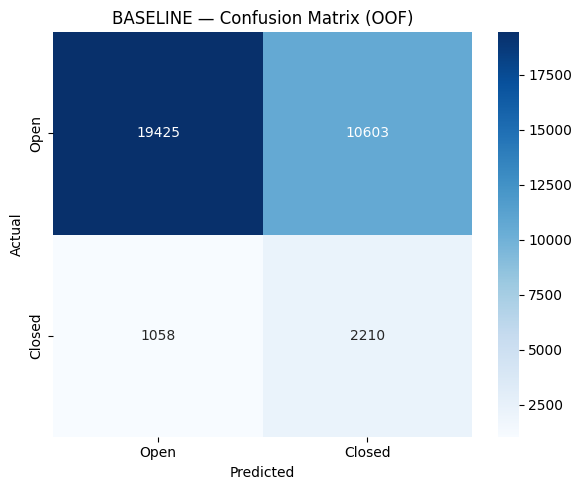

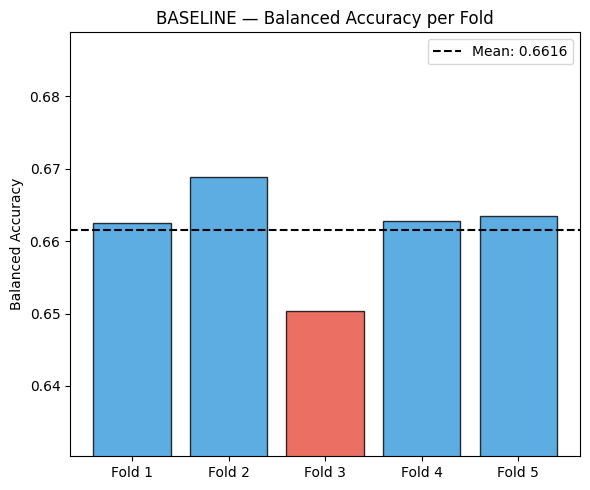

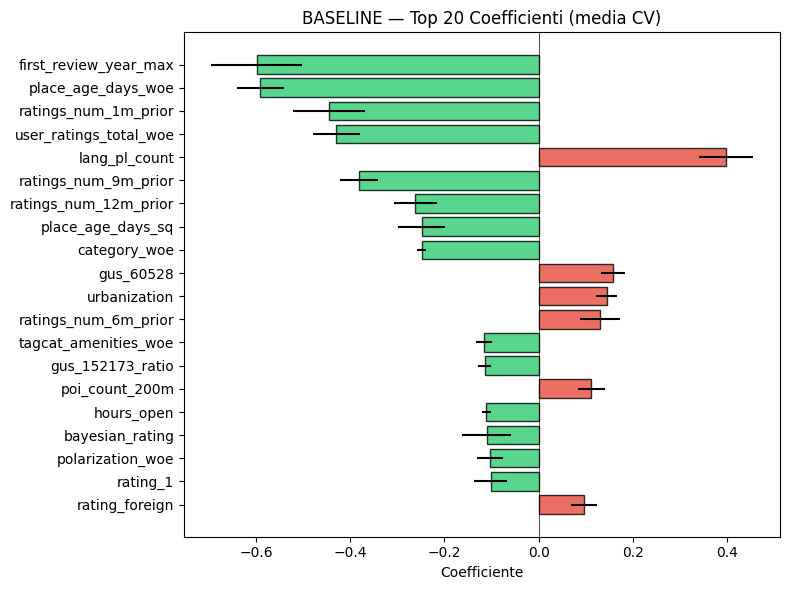

In [131]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title('BASELINE — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05a_baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Balanced Accuracy per Fold ===
fig2, ax2 = plt.subplots(figsize=(6, 5))
fold_scores = cv_results['test_balanced_accuracy']
fold_labels = [f'Fold {i+1}' for i in range(5)]
colors = ['#3498db' if s >= fold_scores.mean() else '#e74c3c' for s in fold_scores]
ax2.bar(fold_labels, fold_scores, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=fold_scores.mean(), color='black', linestyle='--',
            label=f'Mean: {fold_scores.mean():.4f}')
ax2.set_title('BASELINE — Balanced Accuracy per Fold')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_ylim(fold_scores.min() - 0.02, fold_scores.max() + 0.02)
ax2.legend()
plt.tight_layout()
plt.savefig('Data/05a_baseline_folds.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Top 20 Coefficienti ===
fig3, ax3 = plt.subplots(figsize=(8, 6))
coefs = np.array([est.named_steps['model'].coef_[0] for est in cv_results['estimator']])
coef_mean = coefs.mean(axis=0)
coef_std  = coefs.std(axis=0)
top_idx = np.argsort(np.abs(coef_mean))[-20:]
top_names = [feature_names[i] for i in top_idx]
top_coefs = coef_mean[top_idx]
top_stds  = coef_std[top_idx]
color_coefs = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs]
ax3.barh(top_names, top_coefs, xerr=top_stds, color=color_coefs,
         edgecolor='black', alpha=0.8)
ax3.set_title('BASELINE — Top 20 Coefficienti (media CV)')
ax3.set_xlabel('Coefficiente')
ax3.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('Data/05a_baseline_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

In [132]:
# === SALVATAGGIO RISULTATI PER COMPARAZIONE ===
results_baseline = {
    'model': 'Baseline Logistic',
    'balanced_accuracy_mean': cv_results['test_balanced_accuracy'].mean(),
    'balanced_accuracy_std': cv_results['test_balanced_accuracy'].std(),
    'accuracy_mean': cv_results['test_accuracy'].mean(),
    'precision_mean': cv_results['test_precision'].mean(),
    'recall_mean': cv_results['test_recall'].mean(),
    'f1_mean': cv_results['test_f1'].mean(),
}

pd.DataFrame([results_baseline]).to_csv('Data/results_baseline.csv', index=False)
print("✅ Risultati salvati: Data/results_baseline.csv")

✅ Risultati salvati: Data/results_baseline.csv


# === 05b_logistic_L1.py ===

Logistic Regression L1 (LASSO) con GridSearchCV
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy

In [133]:
from sklearn.model_selection import GridSearchCV

# === PIPELINE ===
pipeline_l1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

# === GRID SEARCH ===
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n⏳ GridSearchCV in corso...")
grid = GridSearchCV(
    pipeline_l1,
    param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, target)


⏳ GridSearchCV in corso...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [134]:
# === RISULTATI ===
print(f"\n{'='*60}")
print(f"LOGISTIC REGRESSION L1 (LASSO)")
print(f"{'='*60}")
print(f"Miglior C: {grid.best_params_['model__C']}")
print(f"Miglior Balanced Accuracy (CV): {grid.best_score_:.4f}")


LOGISTIC REGRESSION L1 (LASSO)
Miglior C: 0.1
Miglior Balanced Accuracy (CV): 0.6634


In [143]:
# Dettaglio per ogni C
results_df = pd.DataFrame(grid.cv_results_)
for _, row in results_df.iterrows():
    c_val = row['param_model__C']
    print(f"  C={c_val:<6} → Train: {row['mean_train_score']:.4f}  Test: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    
best_model = grid.best_estimator_.named_steps['model']
print(best_model)    

  C=0.001  → Train: 0.6408  Test: 0.6404 (±0.0127)
  C=0.01   → Train: 0.6678  Test: 0.6616 (±0.0066)
  C=0.1    → Train: 0.6715  Test: 0.6634 (±0.0060)
  C=1.0    → Train: 0.6726  Test: 0.6628 (±0.0064)
  C=10.0   → Train: 0.6725  Test: 0.6628 (±0.0059)
LogisticRegression(C=0.1, class_weight='balanced', max_iter=5000, penalty='l1',
                   random_state=42, solver='saga')


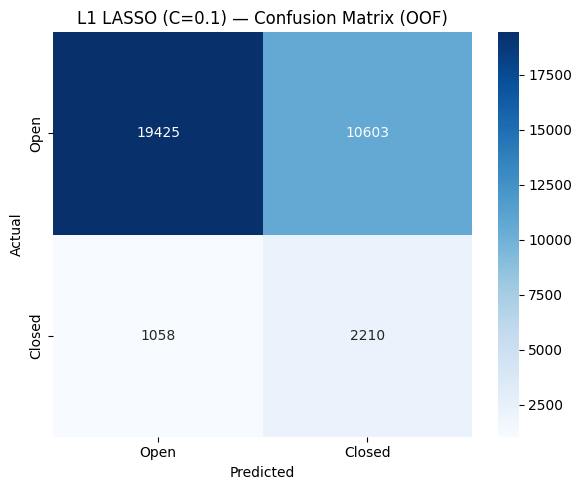

In [139]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title(f'L1 LASSO (C={best_C}) — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05b_L1_cm.png', dpi=150, bbox_inches='tight')
plt.show()

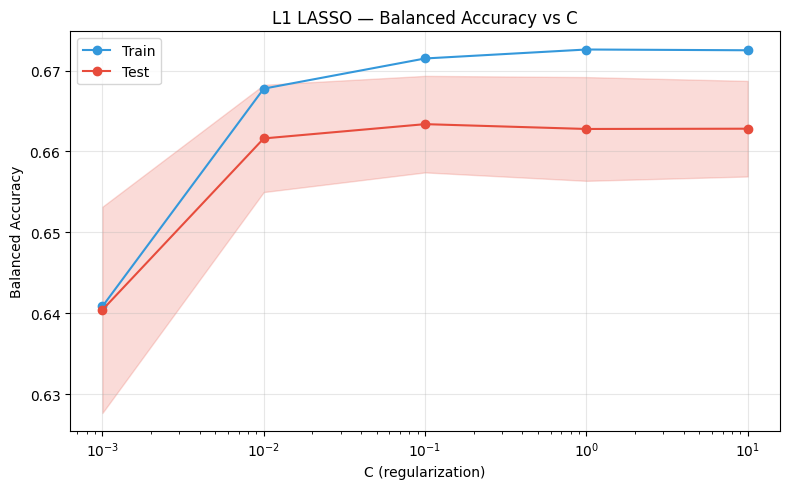

In [140]:
# === GRAFICO 2: Balanced Accuracy vs C ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
c_values = results_df['param_model__C'].astype(float)
ax2.plot(c_values, results_df['mean_train_score'], 'o-', label='Train', color='#3498db')
ax2.plot(c_values, results_df['mean_test_score'], 'o-', label='Test', color='#e74c3c')
ax2.fill_between(c_values,
                 results_df['mean_test_score'] - results_df['std_test_score'],
                 results_df['mean_test_score'] + results_df['std_test_score'],
                 alpha=0.2, color='#e74c3c')
ax2.set_xscale('log')
ax2.set_xlabel('C (regularization)')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title('L1 LASSO — Balanced Accuracy vs C')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/05b_L1_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

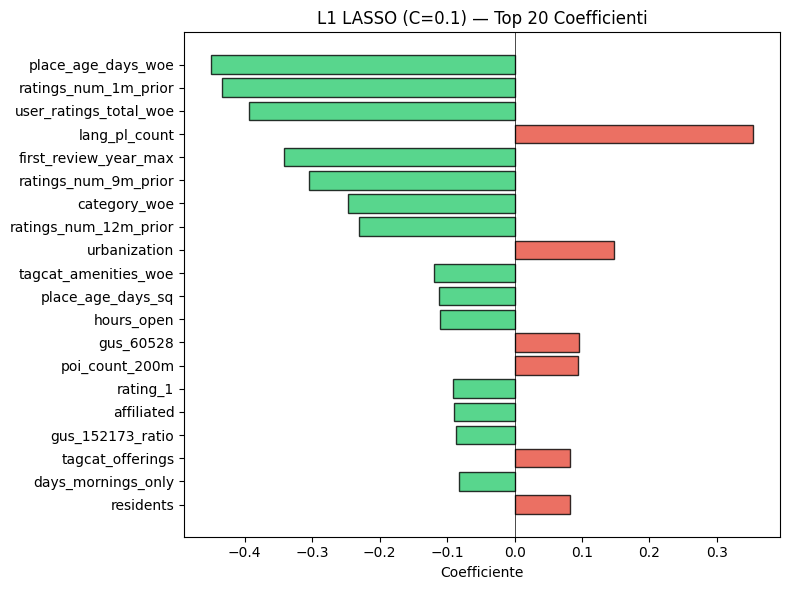

In [144]:
# === GRAFICO 3: Top 20 Coefficienti ===
fig3, ax3 = plt.subplots(figsize=(8, 6))
coef_vals = best_model.coef_[0]
top_idx = np.argsort(np.abs(coef_vals))[-20:]
top_names = [feature_names[i] for i in top_idx]
top_coefs = coef_vals[top_idx]
color_coefs = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs]
ax3.barh(top_names, top_coefs, color=color_coefs, edgecolor='black', alpha=0.8)
ax3.set_title(f'L1 LASSO (C={best_C}) — Top 20 Coefficienti')
ax3.set_xlabel('Coefficiente')
ax3.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('Data/05b_L1_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

In [146]:
# === SALVATAGGIO RISULTATI ===
results = {
    'model': 'Logistic L1 (LASSO)',
    'best_params': str(grid.best_params_),
    'balanced_accuracy_mean': grid.best_score_,
    'balanced_accuracy_std': results_df.loc[grid.best_index_, 'std_test_score'],
    'accuracy_mean': ba,
}
pd.DataFrame([results]).to_csv('Data/results_L1.csv', index=False)
print("\n✅ Risultati salvati: Data/results_L1.csv")



✅ Risultati salvati: Data/results_L1.csv


# === 05c_logistic_L2.py ===

Logistic Regression L2 (Ridge) con GridSearchCV
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy

In [147]:
# === PIPELINE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# === GRID SEARCH ===
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n⏳ GridSearchCV in corso...")
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, target)



⏳ GridSearchCV in corso...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [148]:
# === RISULTATI ===
print(f"\n{'='*60}")
print(f"LOGISTIC REGRESSION L2 (RIDGE)")
print(f"{'='*60}")
print(f"Miglior C: {grid.best_params_['model__C']}")
print(f"Miglior Balanced Accuracy (CV): {grid.best_score_:.4f}")

results_df = pd.DataFrame(grid.cv_results_)
for _, row in results_df.iterrows():
    c_val = row['param_model__C']
    print(f"  C={c_val:<6} → Train: {row['mean_train_score']:.4f}  Test: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")


LOGISTIC REGRESSION L2 (RIDGE)
Miglior C: 0.1
Miglior Balanced Accuracy (CV): 0.6620
  C=0.001  → Train: 0.6679  Test: 0.6613 (±0.0059)
  C=0.01   → Train: 0.6715  Test: 0.6619 (±0.0072)
  C=0.1    → Train: 0.6721  Test: 0.6620 (±0.0062)
  C=1.0    → Train: 0.6724  Test: 0.6616 (±0.0061)
  C=10.0   → Train: 0.6725  Test: 0.6619 (±0.0059)


In [149]:
# === OOF PREDICTIONS ===
oof_preds = np.zeros(len(target))
oof_proba = np.zeros(len(target))

best_C = grid.best_params_['model__C']
for train_idx, val_idx in cv.split(X, target):
    pipe_fold = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            penalty='l2', solver='lbfgs', C=best_C,
            class_weight='balanced', max_iter=2000, random_state=42
        ))
    ])
    pipe_fold.fit(X.iloc[train_idx], target.iloc[train_idx])
    oof_preds[val_idx] = pipe_fold.predict(X.iloc[val_idx])
    oof_proba[val_idx] = pipe_fold.predict_proba(X.iloc[val_idx])[:, 1]

cm = confusion_matrix(target, oof_preds)
ba = balanced_accuracy_score(target, oof_preds)

print(f"\nConfusion Matrix (OOF):")
print(f"                 Predicted 0   Predicted 1")
print(f"  Actual 0 (open):   {cm[0,0]:>6d}        {cm[0,1]:>6d}")
print(f"  Actual 1 (closed): {cm[1,0]:>6d}        {cm[1,1]:>6d}")
print(f"\nBalanced Accuracy OOF: {ba:.4f}")
print(f"\nClassification Report (OOF):")
print(classification_report(target, oof_preds, target_names=['Open', 'Closed']))


Confusion Matrix (OOF):
                 Predicted 0   Predicted 1
  Actual 0 (open):    19431         10597
  Actual 1 (closed):   1056          2212

Balanced Accuracy OOF: 0.6620

Classification Report (OOF):
              precision    recall  f1-score   support

        Open       0.95      0.65      0.77     30028
      Closed       0.17      0.68      0.28      3268

    accuracy                           0.65     33296
   macro avg       0.56      0.66      0.52     33296
weighted avg       0.87      0.65      0.72     33296



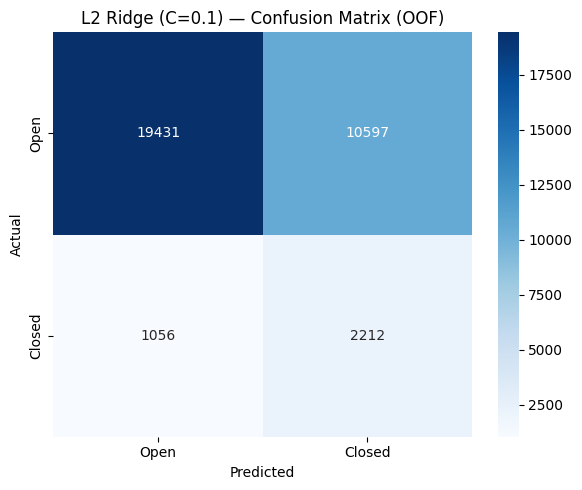

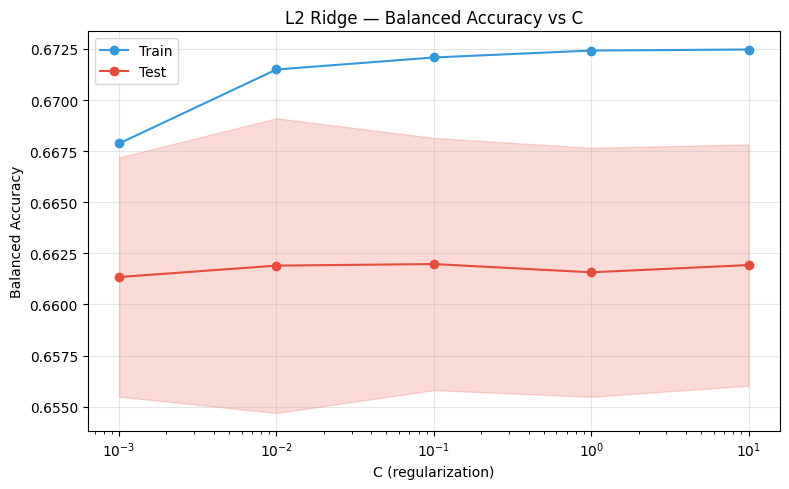

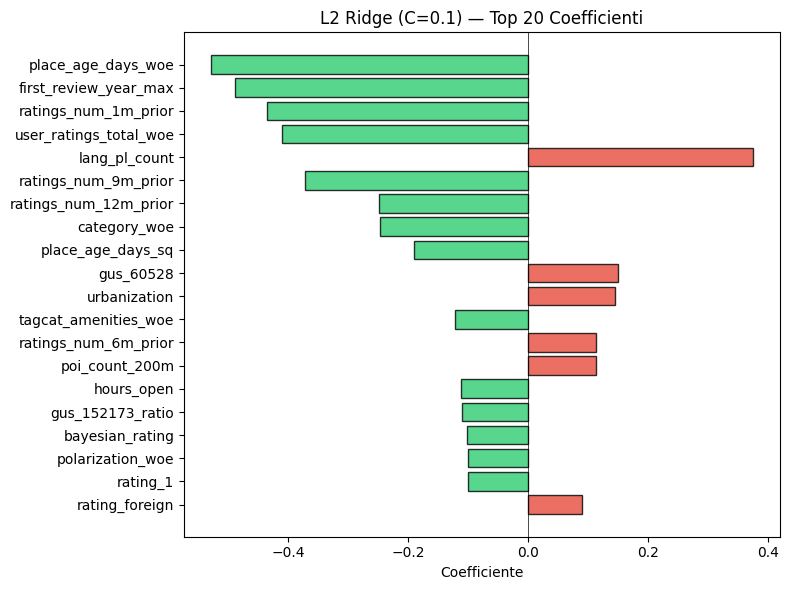

In [150]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title(f'L2 Ridge (C={best_C}) — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05c_L2_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Balanced Accuracy vs C ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
c_values = results_df['param_model__C'].astype(float)
ax2.plot(c_values, results_df['mean_train_score'], 'o-', label='Train', color='#3498db')
ax2.plot(c_values, results_df['mean_test_score'], 'o-', label='Test', color='#e74c3c')
ax2.fill_between(c_values,
                 results_df['mean_test_score'] - results_df['std_test_score'],
                 results_df['mean_test_score'] + results_df['std_test_score'],
                 alpha=0.2, color='#e74c3c')
ax2.set_xscale('log')
ax2.set_xlabel('C (regularization)')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title('L2 Ridge — Balanced Accuracy vs C')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/05c_L2_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Top 20 Coefficienti ===
fig3, ax3 = plt.subplots(figsize=(8, 6))
best_model = grid.best_estimator_.named_steps['model']
coef_vals = best_model.coef_[0]
top_idx = np.argsort(np.abs(coef_vals))[-20:]
top_names = [feature_names[i] for i in top_idx]
top_coefs = coef_vals[top_idx]
color_coefs = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs]
ax3.barh(top_names, top_coefs, color=color_coefs, edgecolor='black', alpha=0.8)
ax3.set_title(f'L2 Ridge (C={best_C}) — Top 20 Coefficienti')
ax3.set_xlabel('Coefficiente')
ax3.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('Data/05c_L2_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

In [151]:
# === SALVATAGGIO RISULTATI ===
results = {
    'model': 'Logistic L2 (Ridge)',
    'best_params': str(grid.best_params_),
    'balanced_accuracy_mean': grid.best_score_,
    'balanced_accuracy_std': results_df.loc[grid.best_index_, 'std_test_score'],
}
pd.DataFrame([results]).to_csv('Data/results_L2.csv', index=False)
print("\n✅ Risultati salvati: Data/results_L2.csv")


✅ Risultati salvati: Data/results_L2.csv


# === 05d_logistic_elasticnet.py ===

Logistic Regression ElasticNet con GridSearchCV
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy


In [152]:
# === PIPELINE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

# === GRID SEARCH ===
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.25, 0.5, 0.75]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("\n⏳ GridSearchCV in corso...")
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, target)


⏳ GridSearchCV in corso...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0.25, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [153]:
# === RISULTATI ===
print(f"\n{'='*60}")
print(f"LOGISTIC REGRESSION ELASTICNET")
print(f"{'='*60}")
print(f"Miglior C: {grid.best_params_['model__C']}")
print(f"Miglior l1_ratio: {grid.best_params_['model__l1_ratio']}")
print(f"Miglior Balanced Accuracy (CV): {grid.best_score_:.4f}")

results_df = pd.DataFrame(grid.cv_results_)
for _, row in results_df.iterrows():
    c_val = row['param_model__C']
    l1 = row['param_model__l1_ratio']
    print(f"  C={c_val:<6} l1_ratio={l1:<5} → Train: {row['mean_train_score']:.4f}  Test: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")


LOGISTIC REGRESSION ELASTICNET
Miglior C: 10
Miglior l1_ratio: 0.5
Miglior Balanced Accuracy (CV): 0.6630
  C=0.01   l1_ratio=0.25  → Train: 0.6710  Test: 0.6609 (±0.0064)
  C=0.01   l1_ratio=0.5   → Train: 0.6696  Test: 0.6591 (±0.0056)
  C=0.01   l1_ratio=0.75  → Train: 0.6680  Test: 0.6599 (±0.0054)
  C=0.1    l1_ratio=0.25  → Train: 0.6730  Test: 0.6615 (±0.0050)
  C=0.1    l1_ratio=0.5   → Train: 0.6723  Test: 0.6614 (±0.0060)
  C=0.1    l1_ratio=0.75  → Train: 0.6719  Test: 0.6616 (±0.0059)
  C=1.0    l1_ratio=0.25  → Train: 0.6731  Test: 0.6629 (±0.0062)
  C=1.0    l1_ratio=0.5   → Train: 0.6732  Test: 0.6629 (±0.0061)
  C=1.0    l1_ratio=0.75  → Train: 0.6732  Test: 0.6630 (±0.0059)
  C=10.0   l1_ratio=0.25  → Train: 0.6730  Test: 0.6630 (±0.0060)
  C=10.0   l1_ratio=0.5   → Train: 0.6730  Test: 0.6630 (±0.0060)
  C=10.0   l1_ratio=0.75  → Train: 0.6730  Test: 0.6630 (±0.0060)


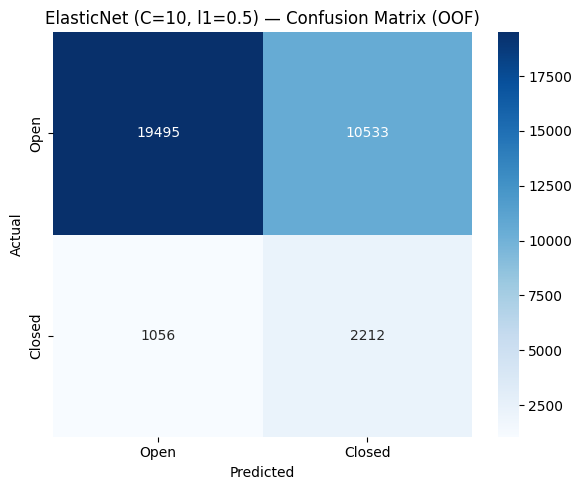

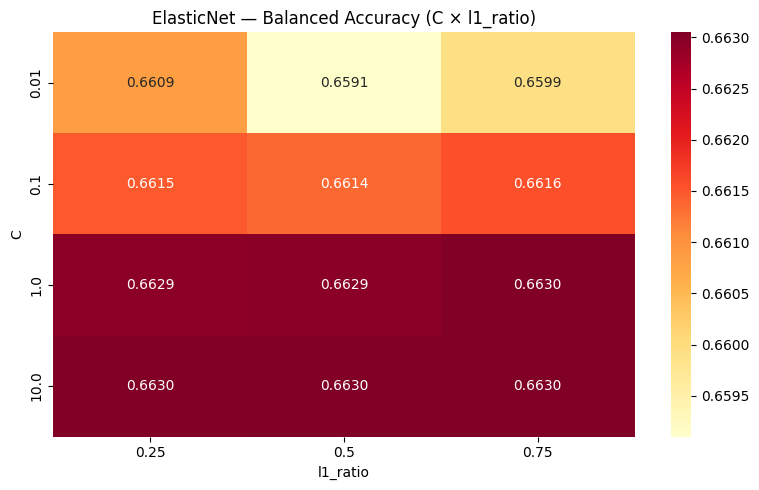

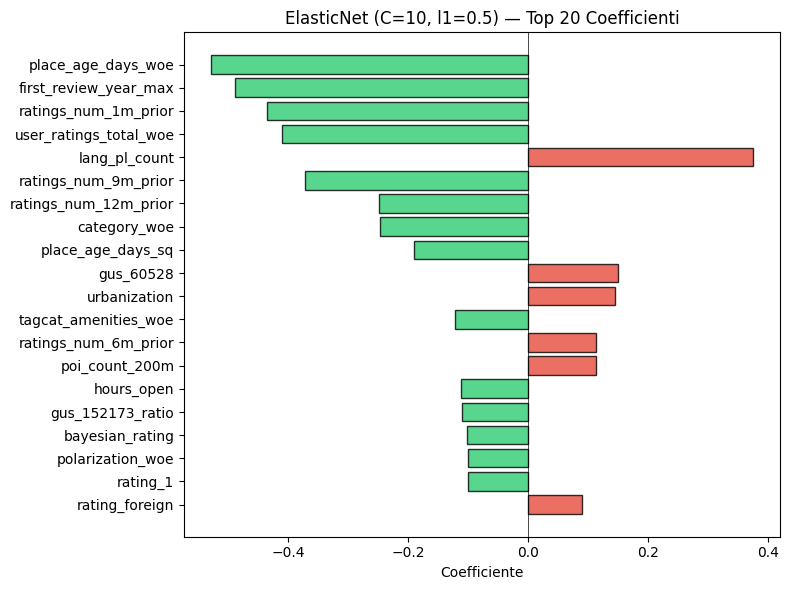

In [155]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title(f'ElasticNet (C={best_C}, l1={best_l1}) — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05d_EN_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Heatmap Balanced Accuracy (C × l1_ratio) ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_model__C',
    columns='param_model__l1_ratio'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2)
ax2.set_title('ElasticNet — Balanced Accuracy (C × l1_ratio)')
ax2.set_ylabel('C')
ax2.set_xlabel('l1_ratio')
plt.tight_layout()
plt.savefig('Data/05d_EN_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Top 20 Coefficienti ===
fig3, ax3 = plt.subplots(figsize=(8, 6))
coef_vals = best_model.coef_[0]
top_idx = np.argsort(np.abs(coef_vals))[-20:]
top_names = [feature_names[i] for i in top_idx]
top_coefs = coef_vals[top_idx]
color_coefs = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs]
ax3.barh(top_names, top_coefs, color=color_coefs, edgecolor='black', alpha=0.8)
ax3.set_title(f'ElasticNet (C={best_C}, l1={best_l1}) — Top 20 Coefficienti')
ax3.set_xlabel('Coefficiente')
ax3.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('Data/05d_EN_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

In [156]:
# === SALVATAGGIO RISULTATI ===
results = {
    'model': 'Logistic ElasticNet',
    'best_params': str(grid.best_params_),
    'balanced_accuracy_mean': grid.best_score_,
    'balanced_accuracy_std': results_df.loc[grid.best_index_, 'std_test_score'],
}
pd.DataFrame([results]).to_csv('Data/results_EN.csv', index=False)
print("\n✅ Risultati salvati: Data/results_EN.csv")


✅ Risultati salvati: Data/results_EN.csv


# === 05e_knn.py ===

K-Nearest Neighbors con GridSearchCV
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy

In [157]:
from sklearn.neighbors import KNeighborsClassifier

# === PIPELINE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# === GRID SEARCH ===
# weights='distance' aiuta con lo sbilanciamento:
# i vicini più prossimi pesano di più nella decisione
param_grid = {
    'model__n_neighbors': [5, 11, 21, 31, 51],
    'model__weights': ['uniform', 'distance'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n⏳ GridSearchCV in corso...")
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, target)


⏳ GridSearchCV in corso...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [5, 11, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [158]:
# === RISULTATI ===
print(f"\n{'='*60}")
print(f"K-NEAREST NEIGHBORS")
print(f"{'='*60}")
print(f"Miglior n_neighbors: {grid.best_params_['model__n_neighbors']}")
print(f"Miglior weights: {grid.best_params_['model__weights']}")
print(f"Miglior Balanced Accuracy (CV): {grid.best_score_:.4f}")

results_df = pd.DataFrame(grid.cv_results_)
for _, row in results_df.iterrows():
    k = row['param_model__n_neighbors']
    w = row['param_model__weights']
    print(f"  k={k:<4} weights={w:<10} → Train: {row['mean_train_score']:.4f}  Test: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")


K-NEAREST NEIGHBORS
Miglior n_neighbors: 5
Miglior weights: distance
Miglior Balanced Accuracy (CV): 0.5178
  k=5    weights=uniform    → Train: 0.5590  Test: 0.5177 (±0.0025)
  k=5    weights=distance   → Train: 1.0000  Test: 0.5178 (±0.0026)
  k=11   weights=uniform    → Train: 0.5148  Test: 0.5067 (±0.0023)
  k=11   weights=distance   → Train: 1.0000  Test: 0.5067 (±0.0023)
  k=21   weights=uniform    → Train: 0.5040  Test: 0.5018 (±0.0008)
  k=21   weights=distance   → Train: 1.0000  Test: 0.5017 (±0.0009)
  k=31   weights=uniform    → Train: 0.5017  Test: 0.5006 (±0.0008)
  k=31   weights=distance   → Train: 1.0000  Test: 0.5009 (±0.0006)
  k=51   weights=uniform    → Train: 0.5000  Test: 0.5000 (±0.0001)
  k=51   weights=distance   → Train: 1.0000  Test: 0.4999 (±0.0001)


In [159]:
# === OOF PREDICTIONS ===
oof_preds = np.zeros(len(target))

best_k = grid.best_params_['model__n_neighbors']
best_w = grid.best_params_['model__weights']
for train_idx, val_idx in cv.split(X, target):
    pipe_fold = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=best_k, weights=best_w))
    ])
    pipe_fold.fit(X.iloc[train_idx], target.iloc[train_idx])
    oof_preds[val_idx] = pipe_fold.predict(X.iloc[val_idx])

cm = confusion_matrix(target, oof_preds)
ba = balanced_accuracy_score(target, oof_preds)

print(f"\nConfusion Matrix (OOF):")
print(f"                 Predicted 0   Predicted 1")
print(f"  Actual 0 (open):   {cm[0,0]:>6d}        {cm[0,1]:>6d}")
print(f"  Actual 1 (closed): {cm[1,0]:>6d}        {cm[1,1]:>6d}")
print(f"\nBalanced Accuracy OOF: {ba:.4f}")
print(f"\nClassification Report (OOF):")
print(classification_report(target, oof_preds, target_names=['Open', 'Closed']))


Confusion Matrix (OOF):
                 Predicted 0   Predicted 1
  Actual 0 (open):    29593           435
  Actual 1 (closed):   3104           164

Balanced Accuracy OOF: 0.5178

Classification Report (OOF):
              precision    recall  f1-score   support

        Open       0.91      0.99      0.94     30028
      Closed       0.27      0.05      0.08      3268

    accuracy                           0.89     33296
   macro avg       0.59      0.52      0.51     33296
weighted avg       0.84      0.89      0.86     33296



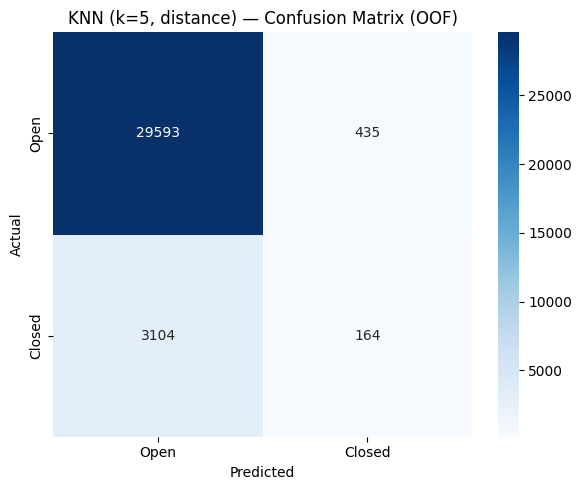

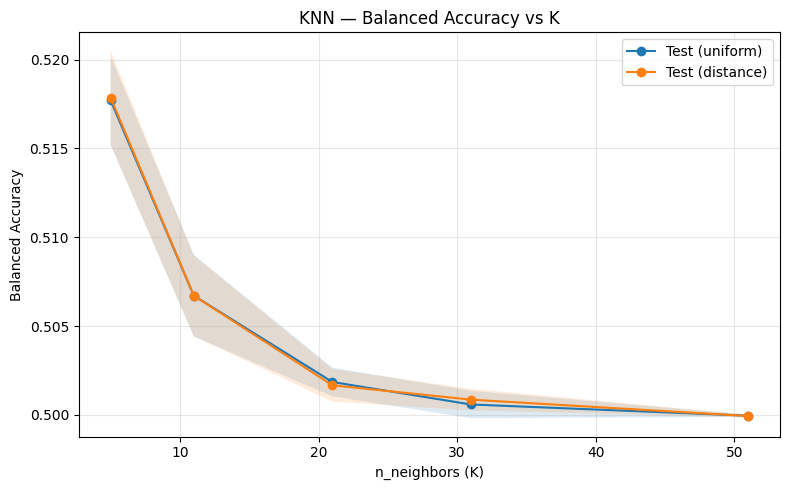

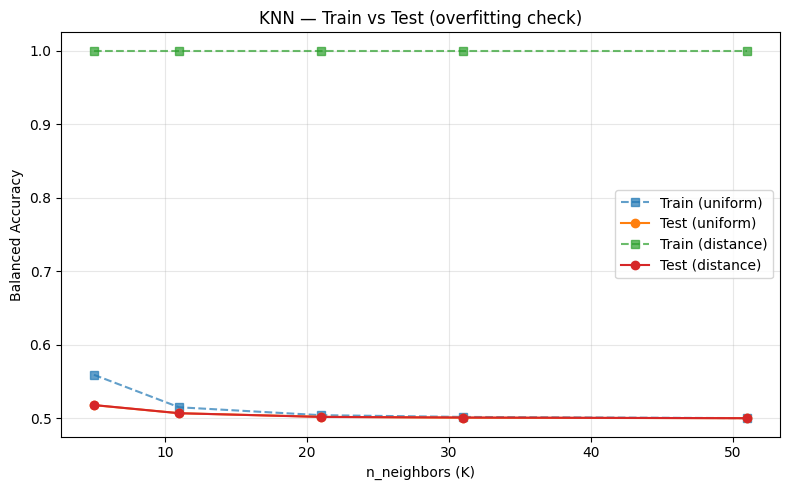

In [160]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title(f'KNN (k={best_k}, {best_w}) — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05e_KNN_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Balanced Accuracy vs K (per weight type) ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
for w_type in ['uniform', 'distance']:
    mask = results_df['param_model__weights'] == w_type
    subset = results_df[mask].sort_values('param_model__n_neighbors')
    k_vals = subset['param_model__n_neighbors'].astype(int)
    ax2.plot(k_vals, subset['mean_test_score'], 'o-', label=f'Test ({w_type})')
    ax2.fill_between(k_vals,
                     subset['mean_test_score'] - subset['std_test_score'],
                     subset['mean_test_score'] + subset['std_test_score'],
                     alpha=0.15)
ax2.set_xlabel('n_neighbors (K)')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_title('KNN — Balanced Accuracy vs K')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/05e_KNN_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Train vs Test (overfitting check) ===
fig3, ax3 = plt.subplots(figsize=(8, 5))
for w_type in ['uniform', 'distance']:
    mask = results_df['param_model__weights'] == w_type
    subset = results_df[mask].sort_values('param_model__n_neighbors')
    k_vals = subset['param_model__n_neighbors'].astype(int)
    ax3.plot(k_vals, subset['mean_train_score'], 's--', label=f'Train ({w_type})', alpha=0.7)
    ax3.plot(k_vals, subset['mean_test_score'], 'o-', label=f'Test ({w_type})')
ax3.set_xlabel('n_neighbors (K)')
ax3.set_ylabel('Balanced Accuracy')
ax3.set_title('KNN — Train vs Test (overfitting check)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/05e_KNN_overfit.png', dpi=150, bbox_inches='tight')
plt.show()


In [161]:
# === SALVATAGGIO RISULTATI ===
results = {
    'model': 'KNN',
    'best_params': str(grid.best_params_),
    'balanced_accuracy_mean': grid.best_score_,
    'balanced_accuracy_std': results_df.loc[grid.best_index_, 'std_test_score'],
}
pd.DataFrame([results]).to_csv('Data/results_KNN.csv', index=False)
print("\n✅ Risultati salvati: Data/results_KNN.csv")


✅ Risultati salvati: Data/results_KNN.csv


# === 05f_svc.py ===

Support Vector Classifier (RBF kernel) con GridSearchCV
Input: restaurants_train_pruned.csv
Metrica: balanced_accuracy

NOTA: SVC è computazionalmente pesante su 33k campioni.
Usiamo probability=True per poter fare analisi threshold nel model evaluation.

In [162]:
from sklearn.svm import SVC

# === PIPELINE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=False,
        random_state=42
    ))
])

# === GRID SEARCH ===
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("\n⏳ GridSearchCV in corso (SVC è lento, pazienza)...")
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='balanced_accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid.fit(X, target)


⏳ GridSearchCV in corso (SVC è lento, pazienza)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [163]:
# === RISULTATI ===
print(f"\n{'='*60}")
print(f"SUPPORT VECTOR CLASSIFIER (RBF)")
print(f"{'='*60}")
print(f"Miglior C: {grid.best_params_['model__C']}")
print(f"Miglior gamma: {grid.best_params_['model__gamma']}")
print(f"Miglior Balanced Accuracy (CV): {grid.best_score_:.4f}")


SUPPORT VECTOR CLASSIFIER (RBF)
Miglior C: 0.1
Miglior gamma: scale
Miglior Balanced Accuracy (CV): 0.6649


In [164]:
results_df = pd.DataFrame(grid.cv_results_)
for _, row in results_df.iterrows():
    c_val = row['param_model__C']
    g = row['param_model__gamma']
    print(f"  C={c_val:<6} gamma={g:<8} → Train: {row['mean_train_score']:.4f}  Test: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

  C=0.1    gamma=scale    → Train: 0.7054  Test: 0.6649 (±0.0059)
  C=0.1    gamma=auto     → Train: 0.7054  Test: 0.6649 (±0.0059)
  C=1.0    gamma=scale    → Train: 0.8341  Test: 0.6488 (±0.0017)
  C=1.0    gamma=auto     → Train: 0.8341  Test: 0.6488 (±0.0017)
  C=10.0   gamma=scale    → Train: 0.9717  Test: 0.5806 (±0.0088)
  C=10.0   gamma=auto     → Train: 0.9717  Test: 0.5806 (±0.0088)


In [165]:
# === OOF PREDICTIONS ===
oof_preds = np.zeros(len(target))

best_C = grid.best_params_['model__C']
best_g = grid.best_params_['model__gamma']
for train_idx, val_idx in cv.split(X, target):
    pipe_fold = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf', C=best_C, gamma=best_g,
            class_weight='balanced', probability=False, random_state=42
        ))
    ])
    pipe_fold.fit(X.iloc[train_idx], target.iloc[train_idx])
    oof_preds[val_idx] = pipe_fold.predict(X.iloc[val_idx])

cm = confusion_matrix(target, oof_preds)
ba = balanced_accuracy_score(target, oof_preds)

print(f"\nConfusion Matrix (OOF):")
print(f"                 Predicted 0   Predicted 1")
print(f"  Actual 0 (open):   {cm[0,0]:>6d}        {cm[0,1]:>6d}")
print(f"  Actual 1 (closed): {cm[1,0]:>6d}        {cm[1,1]:>6d}")
print(f"\nBalanced Accuracy OOF: {ba:.4f}")
print(f"\nClassification Report (OOF):")
print(classification_report(target, oof_preds, target_names=['Open', 'Closed']))


Confusion Matrix (OOF):
                 Predicted 0   Predicted 1
  Actual 0 (open):    19282         10746
  Actual 1 (closed):   1021          2247

Balanced Accuracy OOF: 0.6649

Classification Report (OOF):
              precision    recall  f1-score   support

        Open       0.95      0.64      0.77     30028
      Closed       0.17      0.69      0.28      3268

    accuracy                           0.65     33296
   macro avg       0.56      0.66      0.52     33296
weighted avg       0.87      0.65      0.72     33296



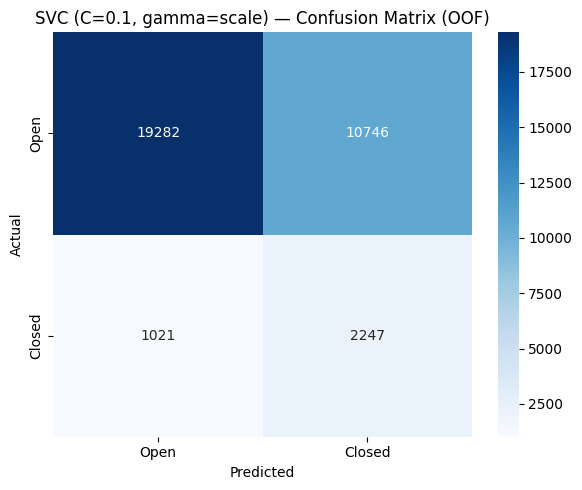

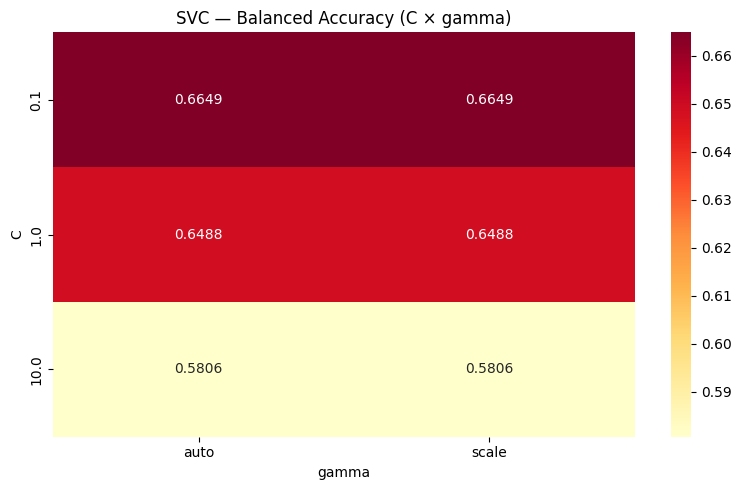

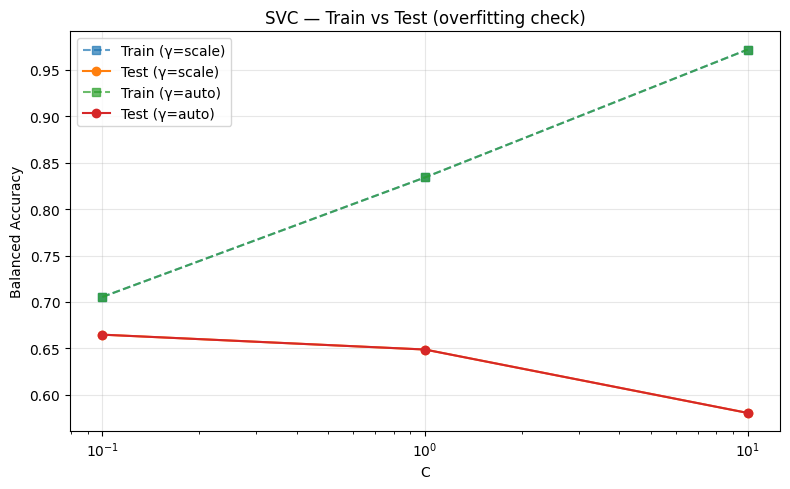

In [166]:
# === GRAFICO 1: Confusion Matrix ===
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
ax1.set_title(f'SVC (C={best_C}, gamma={best_g}) — Confusion Matrix (OOF)')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Data/05f_SVC_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Heatmap Balanced Accuracy (C × gamma) ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_model__C',
    columns='param_model__gamma'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2)
ax2.set_title('SVC — Balanced Accuracy (C × gamma)')
ax2.set_ylabel('C')
ax2.set_xlabel('gamma')
plt.tight_layout()
plt.savefig('Data/05f_SVC_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Train vs Test ===
fig3, ax3 = plt.subplots(figsize=(8, 5))
for g_type in ['scale', 'auto']:
    mask = results_df['param_model__gamma'] == g_type
    subset = results_df[mask].sort_values('param_model__C')
    c_vals = subset['param_model__C'].astype(float)
    ax3.plot(c_vals, subset['mean_train_score'], 's--', label=f'Train (γ={g_type})', alpha=0.7)
    ax3.plot(c_vals, subset['mean_test_score'], 'o-', label=f'Test (γ={g_type})')
ax3.set_xscale('log')
ax3.set_xlabel('C')
ax3.set_ylabel('Balanced Accuracy')
ax3.set_title('SVC — Train vs Test (overfitting check)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/05f_SVC_overfit.png', dpi=150, bbox_inches='tight')
plt.show()


In [167]:
# === SALVATAGGIO RISULTATI ===
results = {
    'model': 'SVC (RBF)',
    'best_params': str(grid.best_params_),
    'balanced_accuracy_mean': grid.best_score_,
    'balanced_accuracy_std': results_df.loc[grid.best_index_, 'std_test_score'],
}
pd.DataFrame([results]).to_csv('Data/results_SVC.csv', index=False)
print("\n✅ Risultati salvati: Data/results_SVC.csv")


✅ Risultati salvati: Data/results_SVC.csv


# === 05g_scaler_penalty_search.py ===

Ricerca sistematica: 3 Scaler × 3 Penalty × C raffinati
Obiettivo: trovare la combinazione che massimizza balanced_accuracy
Input: restaurants_train_pruned.csv

In [170]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# === CONFIGURAZIONE ESPERIMENTI ===
scalers = {
    'StandardScaler': StandardScaler(),
    'PowerTransformer': PowerTransformer(method='yeo-johnson'),
}

experiments = {
    'L1': {
        'penalty': 'l1',
        'solver': 'saga',
        'param_grid': {'model__C': [0.001, 0.008, 0.01, 0.05, 0.1, 1.0, 10.0]},
        'extra_params': {},
    },
    'L2': {
        'penalty': 'l2',
        'solver': 'lbfgs',
        'param_grid': {'model__C': [0.001, 0.008, 0.01, 0.05, 0.1, 1.0, 10.0]},
        'extra_params': {},
    },
    'ElasticNet': {
        'penalty': 'elasticnet',
        'solver': 'saga',
        'param_grid': {
            'model__C': [0.001, 0.008, 0.01, 0.05, 0.1, 1.0, 10.0],
            'model__l1_ratio': [0.5, 0.75, 0.9],
        },
        'extra_params': {},
    },
}

In [171]:
# === ESECUZIONE ===
all_results = []
total = len(scalers) * len(experiments)
counter = 0

print(f"\n{'='*70}")
print(f"RICERCA SISTEMATICA: {len(scalers)} Scaler × {len(experiments)} Penalty = {total} combinazioni")
print(f"{'='*70}\n")

for scaler_name, scaler in scalers.items():
    for exp_name, exp_config in experiments.items():
        counter += 1
        combo_name = f"{scaler_name} + {exp_name}"
        print(f"[{counter}/{total}] {combo_name}...", end=' ')
        
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler.__class__(**scaler.get_params())),
            ('model', LogisticRegression(
                penalty=exp_config['penalty'],
                solver=exp_config['solver'],
                class_weight='balanced',
                max_iter=5000,
                random_state=42,
                **exp_config['extra_params'],
            ))
        ])
        
        grid = GridSearchCV(
            pipeline,
            exp_config['param_grid'],
            cv=cv,
            scoring='balanced_accuracy',
            refit=True,
            return_train_score=True,
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X, target)
        
        best_train = grid.cv_results_['mean_train_score'][grid.best_index_]
        best_test = grid.best_score_
        best_std = grid.cv_results_['std_test_score'][grid.best_index_]
        
        print(f"BA={best_test:.4f} (±{best_std:.4f}) | Train={best_train:.4f} | {grid.best_params_}")
        
        all_results.append({
            'scaler': scaler_name,
            'penalty': exp_name,
            'combination': combo_name,
            'best_params': str(grid.best_params_),
            'ba_test_mean': best_test,
            'ba_test_std': best_std,
            'ba_train_mean': best_train,
            'overfit_gap': best_train - best_test,
        })


RICERCA SISTEMATICA: 2 Scaler × 3 Penalty = 6 combinazioni

[1/6] StandardScaler + L1... BA=0.6630 (±0.0060) | Train=0.6729 | {'model__C': 10.0}
[2/6] StandardScaler + L2... BA=0.6631 (±0.0059) | Train=0.6737 | {'model__C': 10.0}
[3/6] StandardScaler + ElasticNet... BA=0.6630 (±0.0060) | Train=0.6730 | {'model__C': 10.0, 'model__l1_ratio': 0.5}
[4/6] PowerTransformer + L1... BA=0.6769 (±0.0046) | Train=0.6851 | {'model__C': 10.0}
[5/6] PowerTransformer + L2... BA=0.6771 (±0.0041) | Train=0.6853 | {'model__C': 0.05}
[6/6] PowerTransformer + ElasticNet... BA=0.6774 (±0.0042) | Train=0.6857 | {'model__C': 0.1, 'model__l1_ratio': 0.5}


In [172]:
# === TABELLA RISULTATI ===
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('ba_test_mean', ascending=False).reset_index(drop=True)

print(f"\n{'='*70}")
print(f"CLASSIFICA FINALE — TUTTE LE COMBINAZIONI")
print(f"{'='*70}")
print(results_df[['combination', 'ba_test_mean', 'ba_test_std', 'ba_train_mean', 'overfit_gap', 'best_params']].to_string(index=True))


CLASSIFICA FINALE — TUTTE LE COMBINAZIONI
                     combination  ba_test_mean  ba_test_std  ba_train_mean  overfit_gap                                 best_params
0  PowerTransformer + ElasticNet        0.6774       0.0042         0.6857       0.0083   {'model__C': 0.1, 'model__l1_ratio': 0.5}
1          PowerTransformer + L2        0.6771       0.0041         0.6853       0.0083                          {'model__C': 0.05}
2          PowerTransformer + L1        0.6769       0.0046         0.6851       0.0082                          {'model__C': 10.0}
3            StandardScaler + L2        0.6631       0.0059         0.6737       0.0106                          {'model__C': 10.0}
4    StandardScaler + ElasticNet        0.6630       0.0060         0.6730       0.0100  {'model__C': 10.0, 'model__l1_ratio': 0.5}
5            StandardScaler + L1        0.6630       0.0060         0.6729       0.0099                          {'model__C': 10.0}


In [173]:
# Vincitore
winner = results_df.iloc[0]
print(f"\n🏆 VINCITORE: {winner['combination']}")
print(f"   Balanced Accuracy: {winner['ba_test_mean']:.4f} (±{winner['ba_test_std']:.4f})")
print(f"   Parametri: {winner['best_params']}")
print(f"   Overfitting gap: {winner['overfit_gap']:.4f}")


🏆 VINCITORE: PowerTransformer + ElasticNet
   Balanced Accuracy: 0.6774 (±0.0042)
   Parametri: {'model__C': 0.1, 'model__l1_ratio': 0.5}
   Overfitting gap: 0.0083


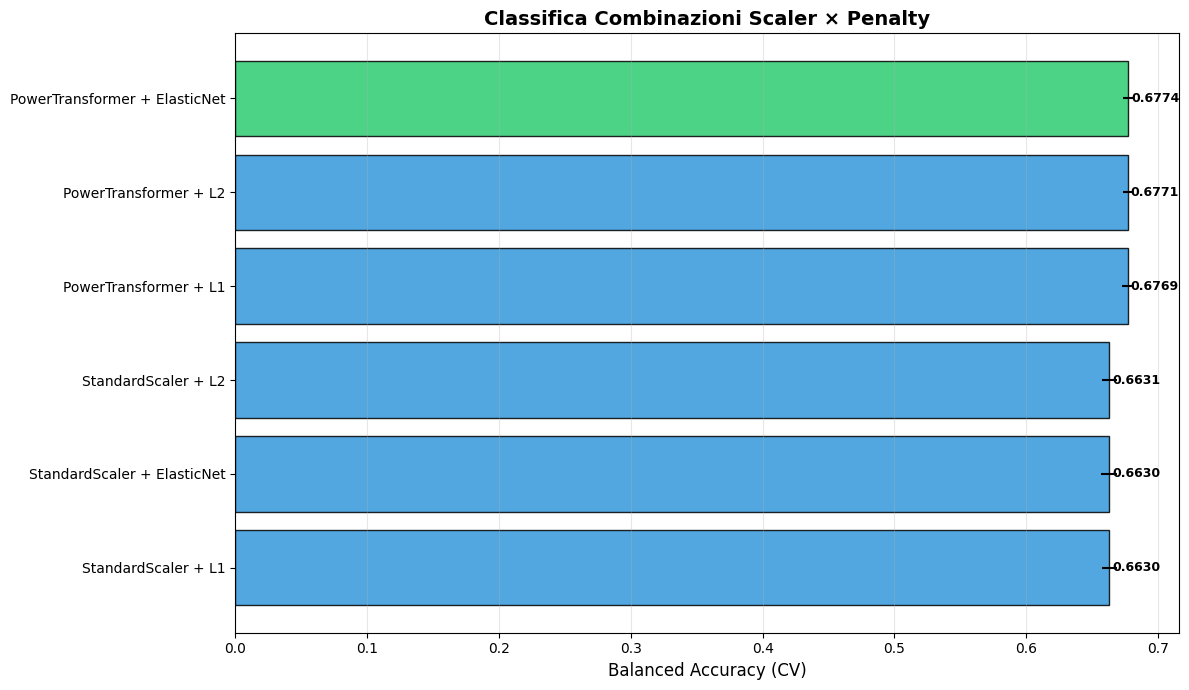

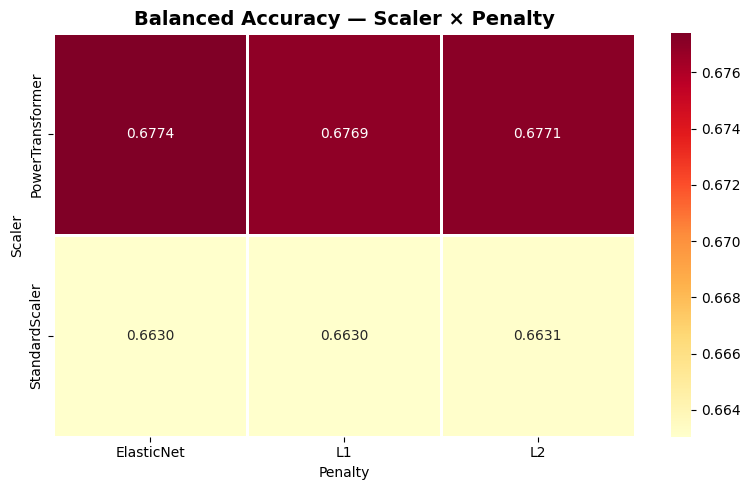

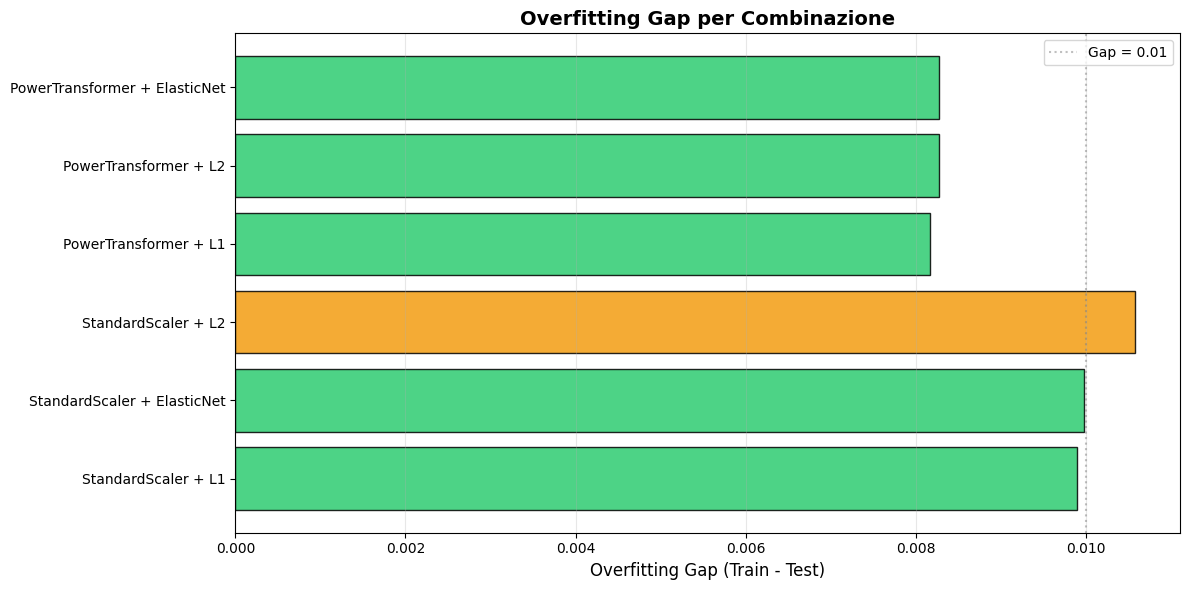

In [174]:
# === GRAFICO 1: Classifica Balanced Accuracy ===
fig1, ax1 = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax1.barh(range(len(results_df)), results_df['ba_test_mean'],
                xerr=results_df['ba_test_std'],
                color=colors, edgecolor='black', alpha=0.85)
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels(results_df['combination'], fontsize=10)
for i, (bar, val) in enumerate(zip(bars, results_df['ba_test_mean'])):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold', fontsize=9)
ax1.set_xlabel('Balanced Accuracy (CV)', fontsize=12)
ax1.set_title('Classifica Combinazioni Scaler × Penalty', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()
plt.tight_layout()
plt.savefig('Data/05g_scaler_penalty_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Heatmap Scaler × Penalty ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
pivot = results_df.pivot_table(
    values='ba_test_mean',
    index='scaler',
    columns='penalty'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2,
            linewidths=1, linecolor='white')
ax2.set_title('Balanced Accuracy — Scaler × Penalty', fontsize=14, fontweight='bold')
ax2.set_ylabel('Scaler')
ax2.set_xlabel('Penalty')
plt.tight_layout()
plt.savefig('Data/05g_scaler_penalty_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 3: Overfitting Gap ===
fig3, ax3 = plt.subplots(figsize=(12, 6))
colors_gap = ['#e74c3c' if g > 0.02 else '#f39c12' if g > 0.01 else '#2ecc71'
              for g in results_df['overfit_gap']]
ax3.barh(range(len(results_df)), results_df['overfit_gap'],
         color=colors_gap, edgecolor='black', alpha=0.85)
ax3.set_yticks(range(len(results_df)))
ax3.set_yticklabels(results_df['combination'], fontsize=10)
ax3.set_xlabel('Overfitting Gap (Train - Test)', fontsize=12)
ax3.set_title('Overfitting Gap per Combinazione', fontsize=14, fontweight='bold')
ax3.axvline(x=0.01, color='gray', linestyle=':', alpha=0.5, label='Gap = 0.01')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig('Data/05g_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [175]:
# === SALVATAGGIO ===
results_df.to_csv('Data/05g_scaler_penalty_results.csv', index=False)
print("\n✅ Risultati salvati: Data/05g_scaler_penalty_results.csv")


✅ Risultati salvati: Data/05g_scaler_penalty_results.csv


# === 06_model_comparison.py ===

Comparazione di tutti i modelli testati
Input: results_*.csv salvati da ogni script 05*
Output: grafici comparativi

In [176]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [178]:
results = pd.DataFrame([
    # --- Vecchi risultati (pre-FE avanzato, 105 feature) ---
    {'model': 'Baseline Logistic (old)', 'balanced_accuracy_mean': 0.6566, 'balanced_accuracy_std': 0.0103, 'features_used': 105},
    {'model': 'PowerTransformer + ElasticNet (old)', 'balanced_accuracy_mean': 0.6695, 'balanced_accuracy_std': 0.0083, 'features_used': 105},
    {'model': 'KNN (old)', 'balanced_accuracy_mean': 0.5224, 'balanced_accuracy_std': 0.0041, 'features_used': 105},
    {'model': 'SVC RBF (old)', 'balanced_accuracy_mean': 0.6522, 'balanced_accuracy_std': 0.0056, 'features_used': 105},
    
    # --- Nuovi risultati (post-FE avanzato + LASSO selection, 84 feature) ---
    {'model': 'StandardScaler + L1', 'balanced_accuracy_mean': 0.6630, 'balanced_accuracy_std': 0.0060, 'features_used': 84},
    {'model': 'StandardScaler + L2', 'balanced_accuracy_mean': 0.6631, 'balanced_accuracy_std': 0.0059, 'features_used': 84},
    {'model': 'StandardScaler + ElasticNet', 'balanced_accuracy_mean': 0.6630, 'balanced_accuracy_std': 0.0060, 'features_used': 84},
    {'model': 'PowerTransformer + L1 ★', 'balanced_accuracy_mean': 0.6769, 'balanced_accuracy_std': 0.0046, 'features_used': 84},
    {'model': 'PowerTransformer + L2 ★', 'balanced_accuracy_mean': 0.6771, 'balanced_accuracy_std': 0.0041, 'features_used': 84},
    {'model': 'PowerTransformer + ElasticNet ★', 'balanced_accuracy_mean': 0.6774, 'balanced_accuracy_std': 0.0042, 'features_used': 84},
])

results = results.sort_values('balanced_accuracy_mean', ascending=False).reset_index(drop=True)

print("=" * 70)
print("COMPARAZIONE MODELLI — BALANCED ACCURACY")
print("=" * 70)
print(results[['model', 'balanced_accuracy_mean', 'balanced_accuracy_std', 'features_used']].to_string(index=False))

print(f"\n→ Miglioramento totale: {0.6774 - 0.6695:.4f} (+{(0.6774-0.6695)*100:.2f} pp)")
print(f"→ Kaggle precedente: 0.663 | CV attuale: 0.6774 | Gap stimato: ~{0.6774-0.663:.3f}")

COMPARAZIONE MODELLI — BALANCED ACCURACY
                              model  balanced_accuracy_mean  balanced_accuracy_std  features_used
    PowerTransformer + ElasticNet ★                  0.6774                 0.0042             84
            PowerTransformer + L2 ★                  0.6771                 0.0041             84
            PowerTransformer + L1 ★                  0.6769                 0.0046             84
PowerTransformer + ElasticNet (old)                  0.6695                 0.0083            105
                StandardScaler + L2                  0.6631                 0.0059             84
                StandardScaler + L1                  0.6630                 0.0060             84
        StandardScaler + ElasticNet                  0.6630                 0.0060             84
            Baseline Logistic (old)                  0.6566                 0.0103            105
                      SVC RBF (old)                  0.6522                 0

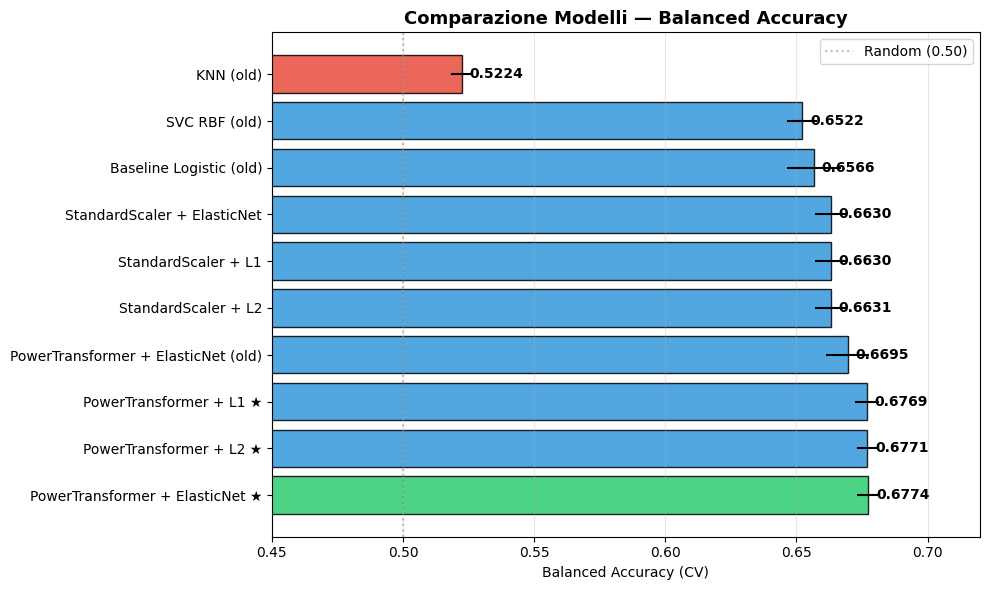

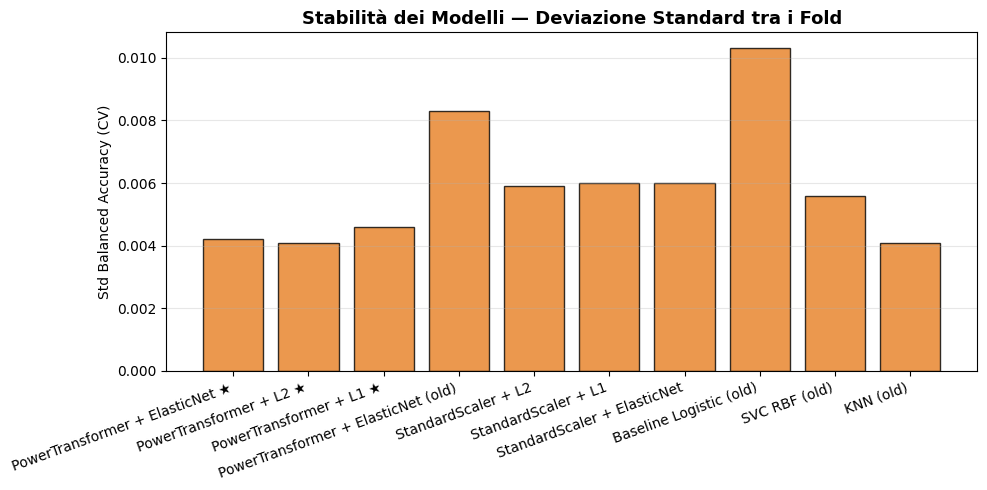


TABELLA RIEPILOGATIVA
                              model  balanced_accuracy_mean  balanced_accuracy_std  features_used
    PowerTransformer + ElasticNet ★                  0.6774                 0.0042             84
            PowerTransformer + L2 ★                  0.6771                 0.0041             84
            PowerTransformer + L1 ★                  0.6769                 0.0046             84
PowerTransformer + ElasticNet (old)                  0.6695                 0.0083            105
                StandardScaler + L2                  0.6631                 0.0059             84
                StandardScaler + L1                  0.6630                 0.0060             84
        StandardScaler + ElasticNet                  0.6630                 0.0060             84
            Baseline Logistic (old)                  0.6566                 0.0103            105
                      SVC RBF (old)                  0.6522                 0.0056            1

In [180]:
# === GRAFICO 1: Balanced Accuracy Comparativa ===
fig1, ax1 = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' if ba > 0.65 else '#e74c3c'
          for i, ba in enumerate(results['balanced_accuracy_mean'])]
bars = ax1.barh(results['model'], results['balanced_accuracy_mean'],
                xerr=results['balanced_accuracy_std'],
                color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, results['balanced_accuracy_mean']):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')

ax1.set_xlabel('Balanced Accuracy (CV)')
ax1.set_title('Comparazione Modelli — Balanced Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlim(0.45, 0.72)
ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Random (0.50)')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Data/06_comparison_balanced_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# === GRAFICO 2: Stabilità (std della balanced accuracy) ===
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(results['model'], results['balanced_accuracy_std'],
        color='#e67e22', edgecolor='black', alpha=0.8)
ax2.set_ylabel('Std Balanced Accuracy (CV)')
ax2.set_title('Stabilità dei Modelli — Deviazione Standard tra i Fold', fontsize=13, fontweight='bold')
ax2.set_xticklabels(results['model'], rotation=20, ha='right')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Data/06_comparison_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# === TABELLA RIEPILOGATIVA ===
print("\n" + "=" * 70)
print("TABELLA RIEPILOGATIVA")
print("=" * 70)
print(results.to_string(index=False))

print("\n🏆 MODELLO MIGLIORE: PowerTransformer + ElasticNet (C=0.1, l1_ratio=0.5)")
print("   Balanced Accuracy: 0.6774 (±0.0042)")
print("   Feature utilizzate: 84 (post LASSO selection)")
print("   Kaggle precedente: 0.663 → miglioramento atteso: +1.4 pp")

results.to_csv('Data/06_model_comparison.csv', index=False)
print("\n✅ Tabella salvata: Data/06_model_comparison.csv")

# === 07_model_evaluation.py ===

Evaluation approfondita — Logistic L1 (LASSO), modello migliore
Include: ROC, Precision-Recall, analisi threshold, costi errori
Input: restaurants_train_pruned.csv
Output: grafici + threshold ottimale

In [182]:
from sklearn.metrics import (confusion_matrix, balanced_accuracy_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train_final.csv')
target = train['status_closed']
X = train.drop(columns=['restaurant_id', 'status_closed'])
feature_names = X.columns.tolist()
print(f"Feature: {X.shape[1]} | Campioni: {X.shape[0]}")

# === OOF PREDICTIONS CON PROBABILITÀ ===
# Usiamo il miglior modello: LASSO con C=0.01
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(target))

print("⏳ Generazione predizioni OOF...")
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, target)):
    pipe_fold = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', PowerTransformer(method='yeo-johnson')),
        ('model', LogisticRegression(
            penalty='elasticnet', solver='saga', C=0.1, l1_ratio=0.5,
            class_weight='balanced', max_iter=5000, random_state=42
        ))
    ])
    pipe_fold.fit(X.iloc[train_idx], target.iloc[train_idx])
    oof_proba[val_idx] = pipe_fold.predict_proba(X.iloc[val_idx])[:, 1]
    print(f"  Fold {fold_idx+1} completato")

# Predizioni con threshold default 0.5
oof_preds_default = (oof_proba >= 0.5).astype(int)
ba_default = balanced_accuracy_score(target, oof_preds_default)
cm_default = confusion_matrix(target, oof_preds_default)

print(f"\n{'='*60}")
print(f"THRESHOLD DEFAULT (0.5)")
print(f"{'='*60}")
print(f"Balanced Accuracy: {ba_default:.4f}")
print(f"Confusion Matrix:")
print(f"  Actual 0 (open):   {cm_default[0,0]:>6d} TN  |  {cm_default[0,1]:>6d} FP")
print(f"  Actual 1 (closed): {cm_default[1,0]:>6d} FN  |  {cm_default[1,1]:>6d} TP")

Feature: 84 | Campioni: 33296
⏳ Generazione predizioni OOF...
  Fold 1 completato
  Fold 2 completato
  Fold 3 completato
  Fold 4 completato
  Fold 5 completato

THRESHOLD DEFAULT (0.5)
Balanced Accuracy: 0.6751
Confusion Matrix:
  Actual 0 (open):    20046 TN  |    9982 FP
  Actual 1 (closed):   1037 FN  |    2231 TP


In [183]:
# =====================================================================
# ANALISI THRESHOLD — Cerchiamo il threshold che massimizza balanced acc
# =====================================================================
thresholds = np.arange(0.05, 0.95, 0.005)
ba_scores = []
recall_0_scores = []
recall_1_scores = []
precision_1_scores = []
f1_1_scores = []

for t in thresholds:
    preds_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(target, preds_t)
    
    # Recall classe 0 (specificity)
    tn, fp, fn, tp = cm_t.ravel()
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0
    
    ba = (recall_0 + recall_1) / 2
    
    ba_scores.append(ba)
    recall_0_scores.append(recall_0)
    recall_1_scores.append(recall_1)
    precision_1_scores.append(precision_1)
    f1_1_scores.append(f1_1)

ba_scores = np.array(ba_scores)
best_idx = np.argmax(ba_scores)
best_threshold = thresholds[best_idx]
best_ba = ba_scores[best_idx]

print(f"\n{'='*60}")
print(f"THRESHOLD OTTIMALE PER BALANCED ACCURACY")
print(f"{'='*60}")
print(f"Threshold ottimale: {best_threshold:.3f}")
print(f"Balanced Accuracy:  {best_ba:.4f}")
print(f"Miglioramento vs 0.5: +{(best_ba - ba_default)*100:.2f} punti percentuali")


THRESHOLD OTTIMALE PER BALANCED ACCURACY
Threshold ottimale: 0.535
Balanced Accuracy:  0.6759
Miglioramento vs 0.5: +0.07 punti percentuali


In [184]:
# Confusion matrix con threshold ottimale
oof_preds_best = (oof_proba >= best_threshold).astype(int)
cm_best = confusion_matrix(target, oof_preds_best)
tn, fp, fn, tp = cm_best.ravel()

print(f"\nConfusion Matrix (threshold={best_threshold:.3f}):")
print(f"  Actual 0 (open):   {tn:>6d} TN  |  {fp:>6d} FP")
print(f"  Actual 1 (closed): {fn:>6d} FN  |  {tp:>6d} TP")
print(f"\nClassification Report (threshold={best_threshold:.3f}):")
print(classification_report(target, oof_preds_best, target_names=['Open', 'Closed']))


Confusion Matrix (threshold=0.535):
  Actual 0 (open):    21460 TN  |    8568 FP
  Actual 1 (closed):   1186 FN  |    2082 TP

Classification Report (threshold=0.535):
              precision    recall  f1-score   support

        Open       0.95      0.71      0.81     30028
      Closed       0.20      0.64      0.30      3268

    accuracy                           0.71     33296
   macro avg       0.57      0.68      0.56     33296
weighted avg       0.87      0.71      0.76     33296



In [185]:
# === ANALISI COSTI ERRORI ===
print(f"{'='*60}")
print(f"ANALISI ERRORI — TIPO 1 vs TIPO 2")
print(f"{'='*60}")
print(f"\n  Con threshold DEFAULT (0.5):")
print(f"    FP (Type I  — predice Closed, è Open):   {cm_default[0,1]:>6d}  ({cm_default[0,1]/len(target)*100:.1f}%)")
print(f"    FN (Type II — predice Open, è Closed):    {cm_default[1,0]:>6d}  ({cm_default[1,0]/len(target)*100:.1f}%)")
print(f"\n  Con threshold OTTIMALE ({best_threshold:.3f}):")
print(f"    FP (Type I  — predice Closed, è Open):   {fp:>6d}  ({fp/len(target)*100:.1f}%)")
print(f"    FN (Type II — predice Open, è Closed):    {fn:>6d}  ({fn/len(target)*100:.1f}%)")
print(f"\n  Trade-off:")
print(f"    Abbassare il threshold → più ristoranti predetti come Closed")
print(f"    → aumenta Recall(Closed) ma aumenta anche i Falsi Positivi")
print(f"    → il threshold ottimale bilancia i due errori per massimizzare BA")

ANALISI ERRORI — TIPO 1 vs TIPO 2

  Con threshold DEFAULT (0.5):
    FP (Type I  — predice Closed, è Open):     9982  (30.0%)
    FN (Type II — predice Open, è Closed):      1037  (3.1%)

  Con threshold OTTIMALE (0.535):
    FP (Type I  — predice Closed, è Open):     8568  (25.7%)
    FN (Type II — predice Open, è Closed):      1186  (3.6%)

  Trade-off:
    Abbassare il threshold → più ristoranti predetti come Closed
    → aumenta Recall(Closed) ma aumenta anche i Falsi Positivi
    → il threshold ottimale bilancia i due errori per massimizzare BA


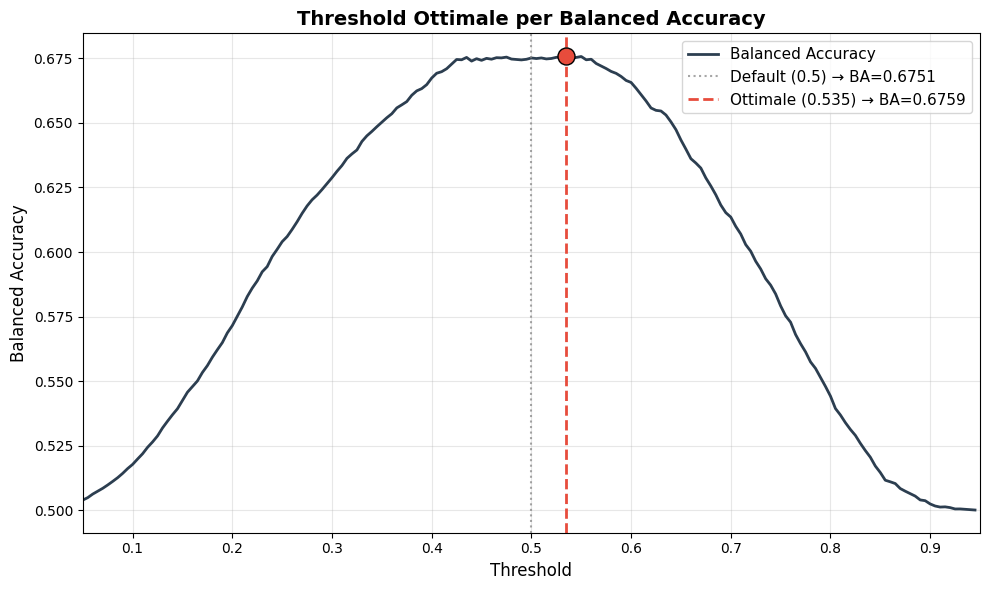

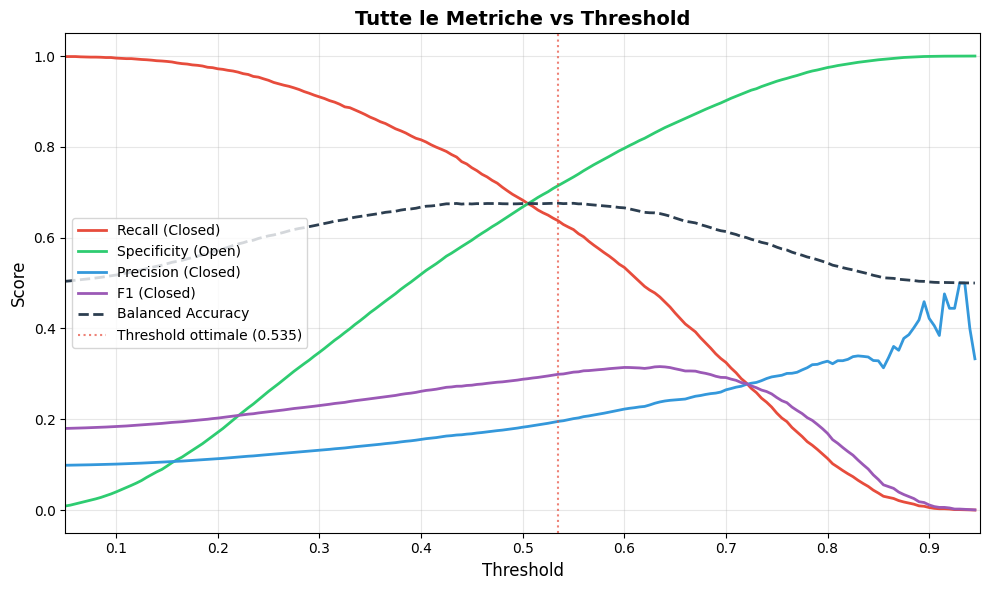

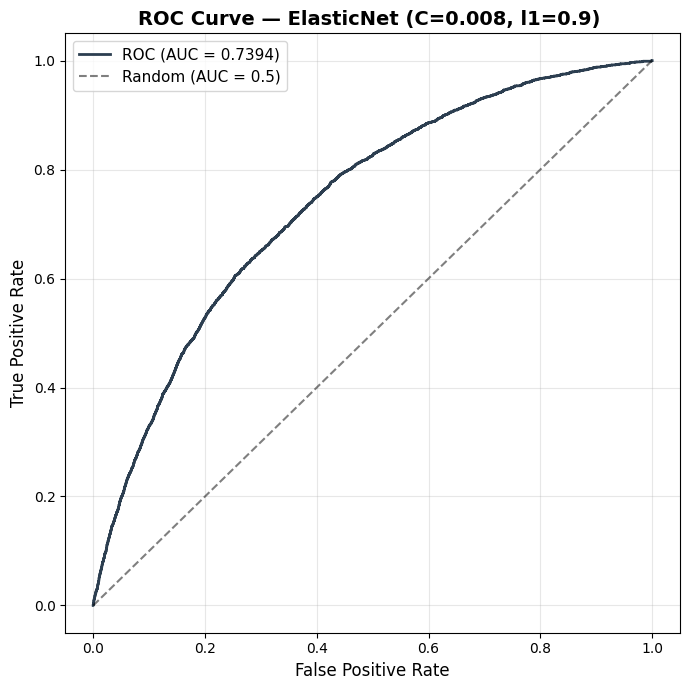

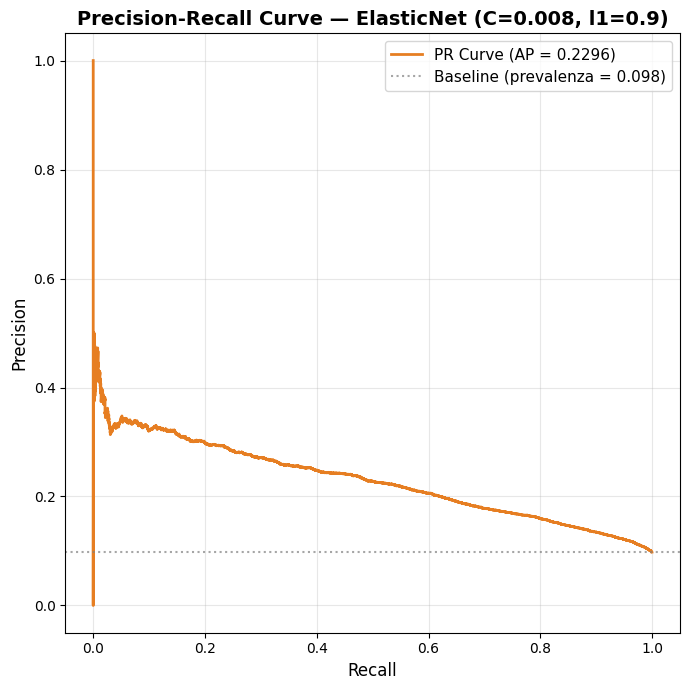

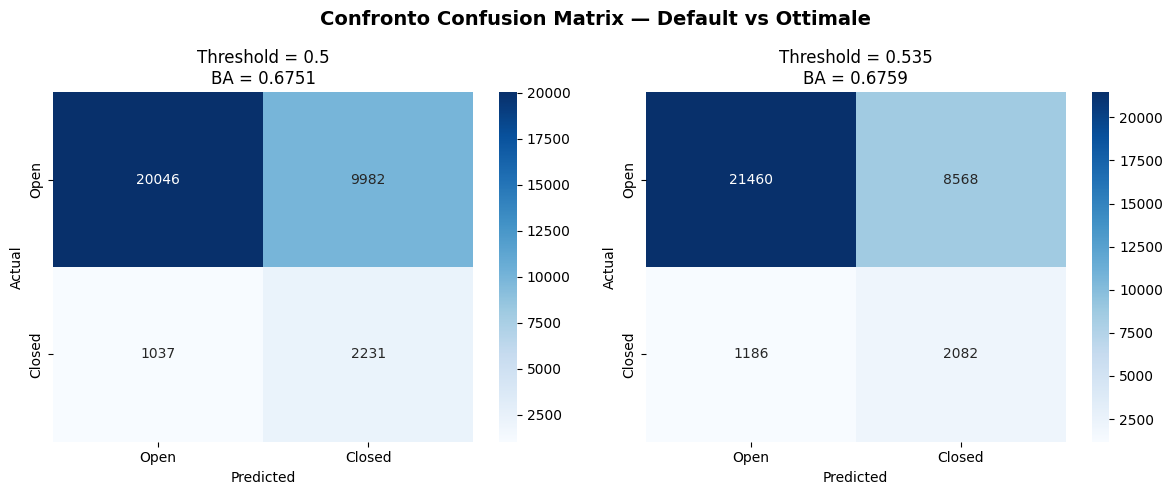

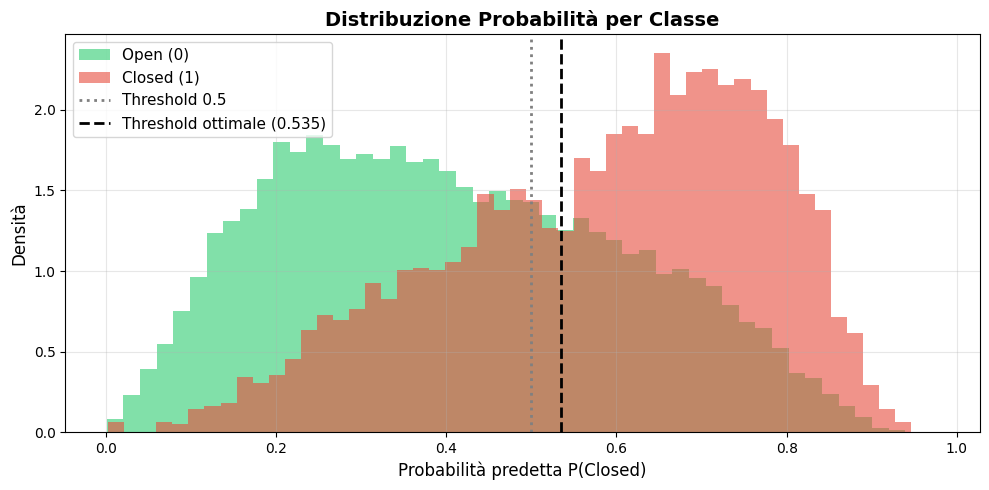


RIEPILOGO EVALUATION
Modello: ElasticNet (C=0.008, l1_ratio=0.9)
ROC AUC: 0.7394
Average Precision: 0.2296

Threshold default (0.5):   BA = 0.6751
Threshold ottimale (0.535): BA = 0.6759
Miglioramento: +0.07 pp

→ Usare threshold = 0.535 per la submission Kaggle


In [186]:
# =====================================================================
# GRAFICO 1: THRESHOLD vs BALANCED ACCURACY (con punto ottimale)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(thresholds, ba_scores, color='#2c3e50', linewidth=2, label='Balanced Accuracy')
ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label=f'Default (0.5) → BA={ba_default:.4f}')
ax1.axvline(x=best_threshold, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Ottimale ({best_threshold:.3f}) → BA={best_ba:.4f}')
ax1.scatter([best_threshold], [best_ba], color='#e74c3c', s=150, zorder=5, edgecolors='black')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Balanced Accuracy', fontsize=12)
ax1.set_title('Threshold Ottimale per Balanced Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.05, 0.95)
plt.tight_layout()
plt.savefig('Data/07_threshold_balanced_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# GRAFICO 2: METRICHE vs THRESHOLD
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(thresholds, recall_1_scores, label='Recall (Closed)', color='#e74c3c', linewidth=2)
ax2.plot(thresholds, recall_0_scores, label='Specificity (Open)', color='#2ecc71', linewidth=2)
ax2.plot(thresholds, precision_1_scores, label='Precision (Closed)', color='#3498db', linewidth=2)
ax2.plot(thresholds, f1_1_scores, label='F1 (Closed)', color='#9b59b6', linewidth=2)
ax2.plot(thresholds, ba_scores, label='Balanced Accuracy', color='#2c3e50', linewidth=2, linestyle='--')
ax2.axvline(x=best_threshold, color='#e74c3c', linestyle=':', alpha=0.7,
            label=f'Threshold ottimale ({best_threshold:.3f})')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Tutte le Metriche vs Threshold', fontsize=14, fontweight='bold')
ax2.legend(loc='center left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.05, 0.95)
plt.tight_layout()
plt.savefig('Data/07_metrics_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# GRAFICO 3: ROC CURVE
# =====================================================================
fpr, tpr, roc_thresholds = roc_curve(target, oof_proba)
roc_auc = auc(fpr, tpr)

fig3, ax3 = plt.subplots(figsize=(7, 7))
ax3.plot(fpr, tpr, color='#2c3e50', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('ROC Curve — ElasticNet (C=0.008, l1=0.9) ', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/07_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# GRAFICO 4: PRECISION-RECALL CURVE
# =====================================================================
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(target, oof_proba)
ap = average_precision_score(target, oof_proba)

fig4, ax4 = plt.subplots(figsize=(7, 7))
ax4.plot(recall_curve, precision_curve, color='#e67e22', linewidth=2,
         label=f'PR Curve (AP = {ap:.4f})')
ax4.axhline(y=target.mean(), color='gray', linestyle=':', alpha=0.7,
            label=f'Baseline (prevalenza = {target.mean():.3f})')
ax4.set_xlabel('Recall', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Precision-Recall Curve — ElasticNet (C=0.008, l1=0.9)', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/07_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# GRAFICO 5: CONFUSION MATRIX CONFRONTO (default vs ottimale)
# =====================================================================
fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=ax5a,
            xticklabels=['Open', 'Closed'], yticklabels=['Open', 'Closed'])
ax5a.set_title(f'Threshold = 0.5\nBA = {ba_default:.4f}', fontsize=12)
ax5a.set_ylabel('Actual')
ax5a.set_xlabel('Predicted')

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax5b,
            xticklabels=['Open', 'Closed'], yticklabels=['Open', 'Closed'])
ax5b.set_title(f'Threshold = {best_threshold:.3f}\nBA = {best_ba:.4f}', fontsize=12)
ax5b.set_ylabel('Actual')
ax5b.set_xlabel('Predicted')

fig5.suptitle('Confronto Confusion Matrix — Default vs Ottimale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Data/07_confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# GRAFICO 6: DISTRIBUZIONE PROBABILITÀ PER CLASSE
# =====================================================================
fig6, ax6 = plt.subplots(figsize=(10, 5))
ax6.hist(oof_proba[target == 0], bins=50, alpha=0.6, color='#2ecc71', label='Open (0)', density=True)
ax6.hist(oof_proba[target == 1], bins=50, alpha=0.6, color='#e74c3c', label='Closed (1)', density=True)
ax6.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Threshold 0.5')
ax6.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold ottimale ({best_threshold:.3f})')
ax6.set_xlabel('Probabilità predetta P(Closed)', fontsize=12)
ax6.set_ylabel('Densità', fontsize=12)
ax6.set_title('Distribuzione Probabilità per Classe', fontsize=14, fontweight='bold')
ax6.legend(fontsize=11)
ax6.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Data/07_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# === RIEPILOGO FINALE ===
print(f"\n{'='*60}")
print(f"RIEPILOGO EVALUATION")
print(f"{'='*60}")
print(f"Modello: ElasticNet (C=0.008, l1_ratio=0.9)")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {ap:.4f}")
print(f"\nThreshold default (0.5):   BA = {ba_default:.4f}")
print(f"Threshold ottimale ({best_threshold:.3f}): BA = {best_ba:.4f}")
print(f"Miglioramento: +{(best_ba - ba_default)*100:.2f} pp")
print(f"\n→ Usare threshold = {best_threshold:.3f} per la submission Kaggle")

In [187]:
# Salviamo il threshold ottimale per lo script di submission
eval_results = {
    'model': 'ElasticNet (C=0.1, l1=0.5)',
    'C': 0.1,
    'l1_ratio': 0.5,
    'threshold_default': 0.5,
    'ba_default': ba_default,
    'threshold_optimal': best_threshold,
    'ba_optimal': best_ba,
    'roc_auc': roc_auc,
    'average_precision': ap,
}
pd.DataFrame([eval_results]).to_csv('Data/07_evaluation_results.csv', index=False)
print("\n✅ Risultati salvati: Data/07_evaluation_results.csv")


✅ Risultati salvati: Data/07_evaluation_results.csv


# === 08_submission.py ===

Submission Kaggle — PowerTransformer + ElasticNet (C=0.008, l1_ratio=0.9)
Threshold: 0.495
Input: restaurants_train_pruned.csv, restaurants_test_pruned.csv
Output: submission.csv

In [188]:
# === CARICAMENTO ===
train = pd.read_csv('Data/restaurants_train_final.csv')
test  = pd.read_csv('Data/restaurants_test_final.csv')

target = train['status_closed']
X_train = train.drop(columns=['restaurant_id', 'status_closed'])
X_test  = test.drop(columns=['restaurant_id'])

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (33296, 84)
Test:  (8325, 84)


In [189]:
# === PIPELINE FINALE ===
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson')),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=0.1,
        l1_ratio=0.5,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

# === FIT SU TUTTO IL TRAIN ===
print("\n⏳ Training sul dataset completo...")
pipeline.fit(X_train, target)
print("✅ Training completato")



⏳ Training sul dataset completo...
✅ Training completato


In [190]:
# === PREDIZIONI ===
THRESHOLD = 0.535

test_proba = pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= THRESHOLD).astype(int)

print(f"\nThreshold: {THRESHOLD}")
print(f"Predizioni sul test set:")
print(f"  Classe 0 (Open):   {(test_preds == 0).sum()}")
print(f"  Classe 1 (Closed): {(test_preds == 1).sum()}")
print(f"  % Closed: {test_preds.mean()*100:.1f}%")


Threshold: 0.535
Predizioni sul test set:
  Classe 0 (Open):   5689
  Classe 1 (Closed): 2636
  % Closed: 31.7%


In [191]:
# === CREAZIONE FILE SUBMISSION ===
submission = pd.DataFrame({
    'restaurant_id': test['restaurant_id'],
    'status_closed': test_preds
})

# Verifica formato
print(f"\nSubmission shape: {submission.shape}")
print(f"Colonne: {submission.columns.tolist()}")
print(f"Prime righe:")
print(submission.head(10))

# Confronto con sample submission
sample = pd.read_csv('Data/restaurant_sample_submission.csv')
print(f"\nSample submission shape: {sample.shape}")
assert submission.shape == sample.shape, "⚠️ Shape diversa dal sample!"
assert list(submission.columns) == list(sample.columns), "⚠️ Colonne diverse dal sample!"
print("✅ Formato conforme al sample submission")


Submission shape: (8325, 2)
Colonne: ['restaurant_id', 'status_closed']
Prime righe:
   restaurant_id  status_closed
0      192311983              0
1      621181627              0
2      119760055              0
3      729596929              0
4      116589396              1
5      603782660              0
6      439815837              0
7      636142592              0
8      205744561              0
9      300407400              1

Sample submission shape: (8325, 2)
✅ Formato conforme al sample submission


In [192]:
# === SALVATAGGIO ===
submission.to_csv('Data/submission.csv', index=False)
print("\n✅ File salvato: Data/submission.csv")
print("\n📤 Carica Data/submission.csv su Kaggle per ottenere il punteggio!")


✅ File salvato: Data/submission.csv

📤 Carica Data/submission.csv su Kaggle per ottenere il punteggio!
